In [1]:
import pandas as pd
from astropy.coordinates import SkyCoord
import os
import numpy as np
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt


/arc/home/calvin/FRB/frb/halos/hmf.py:51: UserWarning: hmf_emulator not imported.  Hope you are not intending to use the hmf.py module..
  warnings.warn("hmf_emulator not imported.  Hope you are not intending to use the hmf.py module..")


0 /30
1 /30
2 /30
3 /30
4 /30
5 /30
6 /30
7 /30
8 /30
9 /30
10 /30
11 /30
12 /30
13 /30
14 /30
15 /30
16 /30
17 /30
18 /30
19 /30
20 /30
21 /30
22 /30
23 /30
24 /30
25 /30
26 /30
27 /30
28 /30
29 /30


In [ ]:
from frb.dm import igm
z_interp = np.geomspace(0.001,1,num = 30)
dm_igm_interp = []
for ii, z_interp_i in enumerate(z_interp):
    dm_igm_interp.append(igm.average_DM(z_interp_i))
    print(ii,'/30')
dm_igm_interp= np.array([di.value for di in dm_igm_interp])


In [3]:
import dustmaps
from dustmaps.sfd import SFDQuery
import dustmaps.sfd as sfd
sfd = SFDQuery()
e_b_minus_v = sfd(SkyCoord('16h02m04.272s -11d17m17.32s',frame = 'icrs')) # amplitude of extinction curve vs wavelength
r_v = 3.1 # shape
a_v = r_v * e_b_minus_v # get A_v = R_V * E(B-V) ??? Let's pretend I understand why this is the case
import extinction
evs = []
ext_value_mags = extinction.fm07(wave = np.array([12000.0]), a_v = a_v, unit = 'aa') # extrapolate extinction to 6000 angstroms
evs.append(ext_value_mags)
evs = np.squeeze(evs)        

In [4]:
import numpy as np

import pandas as pd
import os
import json
from frb.surveys.panstarrs import Pan_STARRS_Survey
from frb.surveys.decals import DECaL_Survey
from astropy.coordinates import SkyCoord
from astropy import units as u
from astropy.cosmology import Planck18
import astropy.units as u
import pyne2001
import astropy.coordinates as coord
from frb.surveys.decals import DECaL_Survey
from frb.surveys.panstarrs import Pan_STARRS_Survey

def get_ne2001(c_icrs,get_scatt = True):
    dm_ne2001 = np.zeros(len(c_icrs))
    tau600_ne2001 = np.zeros(len(c_icrs))

    for ii,(gl,gb) in enumerate(zip(c_icrs.galactic.l,c_icrs.galactic.b)):
        ne2001_pred = pyne2001.get_dm_full(gl.value,gb.value,dist_kpc = 100.0)
        #print(f"dist: {ne2001_pred['DIST']}")
        dm_ne2001[ii] = ne2001_pred['DM']
        tau600_ne2001[ii] = ne2001_pred['TAU'] * (1/0.6)**4
    if get_scatt:
        return dm_ne2001,tau600_ne2001
    else:
        return dm_ne2001

def calc_ne2001(df):
    if 'primary_ra' in df.keys():
        sources = coord.SkyCoord(df['primary_ra'],df['primary_dec'],unit = 'deg',frame = 'icrs')
    elif 'frb_ra' in df.keys():
        sources = coord.SkyCoord(df['frb_ra'],df['frb_dec'],unit = 'deg',frame = 'icrs')
    dm_ne2001,tau600_ne2001 = get_ne2001(sources,get_scatt=True)
    df['DM_NE2001'] = dm_ne2001
    df['tau_NE2001_600'] = tau600_ne2001
    return df

def calc_extinction_fm07(df):
    """Add Galactic extinction from F & M 2007, given either FRB coordinates or HG coordinates in a pandas dataframe"""
    import dustmaps
    from dustmaps.sfd import SFDQuery
    import dustmaps.sfd as sfd
    sfd = SFDQuery()
    if 'primary_ra' in df.keys(): # use hg coords if we have them
        sources = coord.SkyCoord(df['primary_ra'],df['primary_dec'],unit = 'deg',frame = 'icrs')
    elif 'frb_ra' in df.keys(): # otherwise use FRB coords
        sources = coord.SkyCoord(df['frb_ra'],df['frb_dec'],unit = 'deg',frame = 'icrs')
    e_b_minus_v = sfd(sources) # amplitude of extinction curve vs wavelength
    r_v = 3.1 # shape
    a_v = r_v * e_b_minus_v # get A_v = R_V * E(B-V) ??? Let's pretend I understand why this is the case
    import extinction
    evs = []
    for av in a_v:
        ext_value_mags = extinction.fm07(wave = np.array([6000.0]), a_v = av, unit = 'aa') # extrapolate extinction to 6000 angstroms
        evs.append(ext_value_mags)
    evs = np.squeeze(evs)        
    df['extinction_mags'] = evs
    return df

def calc_yt20(df):
    def calculate_halo_dm_yt20(l, b):
        coeffs = np.array(
            [
                [250.12, -871.06, 1877.5, -2553.0, 2181.3, -1127.5, 321.72, -38.905],
                [-154.82, 783.43, -1593.9, 1727.6, -1046.5, 332.09, -42.815, 0],
                [-116.72, -76.815, 428.49, -419.00, 174.60, -27.610, 0, 0],
                [216.67, -193.30, 12.234, 32.145, -8.3602, 0, 0, 0],
                [-129.95, 103.80, -22.800, 0.44171, 0, 0, 0, 0],
                [39.652, -21.398, 2.7694, 0, 0, 0, 0, 0],
                [-6.1926, 1.6162, 0, 0, 0, 0, 0, 0],
                [0.39346, 0, 0, 0, 0, 0, 0, 0],
            ]
        )
        l = np.mod(l + 180,360) - 180
        l_absolute = np.abs(np.deg2rad(l))
        b_absolute = np.abs(np.deg2rad(b))
        DM_halo = 0
        for ii in range(8):
            for jj in range(8):
                DM_halo += coeffs[ii, jj] * l_absolute ** ii * b_absolute ** jj
        return DM_halo # u.pc / u.cm ** 3
    if 'primary_ra' in df.keys():
        sources = coord.SkyCoord(df['primary_ra'],df['primary_dec'],unit = 'deg',frame = 'icrs')
    elif 'frb_ra' in df.keys():
        sources = coord.SkyCoord(df['frb_ra'],df['frb_dec'],unit = 'deg',frame = 'icrs')
    df['DM_YT20'] = calculate_halo_dm_yt20(l = sources.galactic.l.deg,b = sources.galactic.b.deg)
    return df

def calc_dm_igm(df,source = 'zspec'):
    from frb.dm import igm
    for evid,row in df.iterrows():
        if source == 'zphot': 
            best_redshift = row['primary_z_phot_median']
        elif source == 'zspec':
            best_redshift = row['primary_z_spec']
        elif source == 'mix':
            if row['primary_z_spec'] > 0:
                best_redshift = row['primary_z_spec']
            elif row['primary_z_phot_median'] > 0:
                best_redshift = row['primary_z_phot_median']
            else:
                best_redshift = -1
        if best_redshift > 0:
            dm_igm = np.interp(xp = z_interp, fp = dm_igm_interp, x = best_redshift)
            df.at[evid,'dm_igm'] = dm_igm
        else:
            df.at[evid,'dm_igm'] = np.nan
    return df

def calc_dmh(df):
    dmh = (df['DM'] - df['dm_igm'] - df['DM_NE2001'] - df['DM_YT20']) / (1 + df['primary_z_spec'])
    df['DM_host_restframe'] = dmh
    return df

def calc_Mr(df,source='zspec'):
    if source == 'zspec':
        dist_mod = Planck18.distmod(np.clip(df['primary_z_spec'].values,a_min = 0,a_max = np.inf)).value
    if source == 'zphot':
        dist_mod = Planck18.distmod(np.clip(df['primary_z_phot'].values,a_min = 0,a_max = np.inf)).value
    df['M_r'] = df['primary_mag'] - df['extinction_mags'] - dist_mod
    return df

# Leung 2024

In [29]:
final = pd.read_csv(os.path.join('/arc/home/calvin/kko_host_paper','data_products/kko_full_cat.csv'))

# Leung
final = calc_Mr(final)
exclude = (final['chime_event_id'] != 339589360) * (final['chime_event_id'] != 342760050) #clusters
final_zspec = calc_dm_igm(final,source = 'zspec')
final_zphot = calc_dm_igm(final,source = 'zphot')
fiducial = (final['primary_P_Ox'] > 0.9) * (final['primary_mag'] < 22) * (final['primary_z_spec'] > 0)
final.set_index('name',inplace=True)
final_zspec = calc_dmh(final_zspec)
final_zphot = calc_dmh(final_zphot)


/opt/pysetup/.venv/lib/python3.8/site-packages/astropy/cosmology/flrw/base.py:1341: RuntimeWarning: divide by zero encountered in log10
  val = 5.0 * np.log10(abs(self.luminosity_distance(z).value)) + 25.0


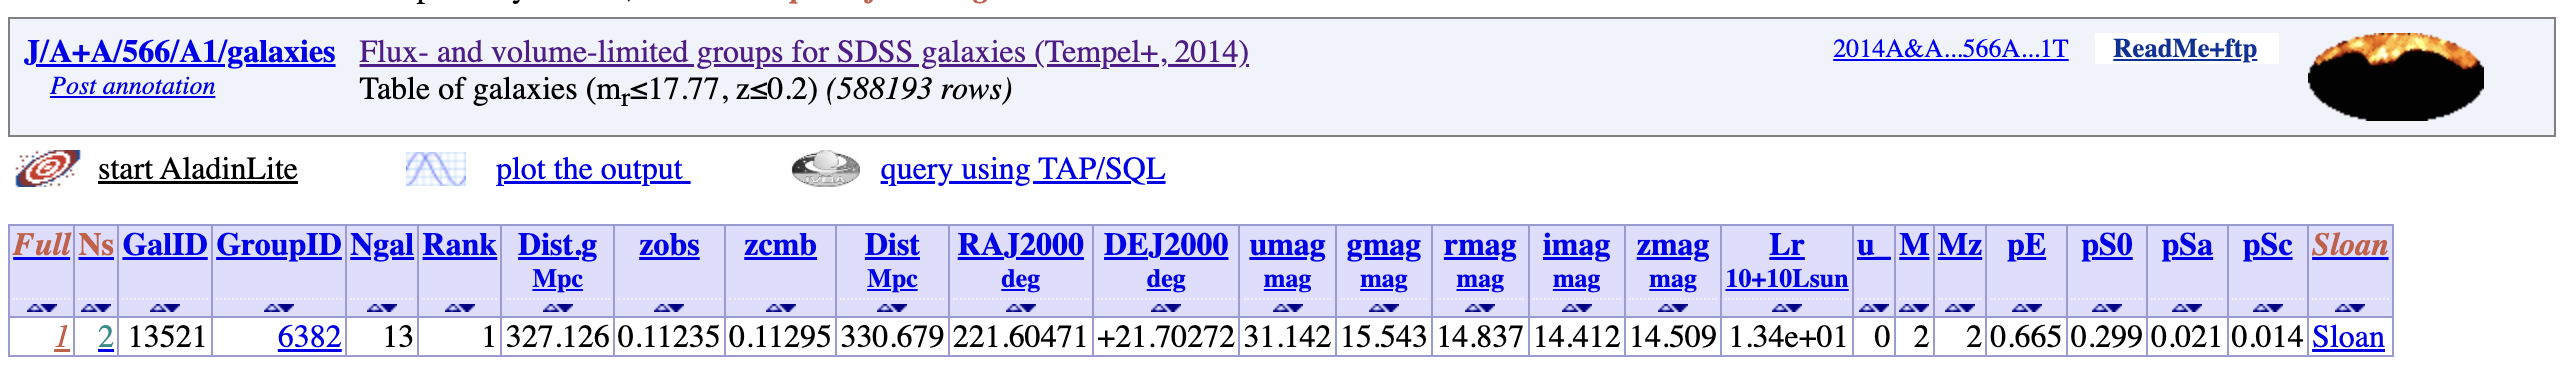

In [31]:
final[final.index == 'FRB20231204A'][['primary_ra','primary_dec','DM','dm_igm','DM_YT20','DM_NE2001','primary_z_spec','primary_mag']]

,primary_ra,primary_dec,DM,dm_igm,DM_YT20,DM_NE2001,primary_z_spec,primary_mag
name,,,,,,,,
FRB20231204A,207.999403,48.120566,222.0,40.892086,32.003043,29.8287,0.0644,15.397451


# Bhardwaj 2024: the old R4 paper (20181030A) and also 4 new FRBs 
Add DM IGM, DM NE2001, DM YT20

In [67]:
def get_bhardwaj():
    coords_bhardwaj2024 = ['10h34m20.1s +73d45m05s','23h14m52s +48d20m25s',    '12h03m43s +27d33m09s',    '04h23m16s +16d04m02s',    '17h02m42s +21d34m35s']
    scb =  SkyCoord(coords_bhardwaj2024,frame = 'icrs')
    _bhardwaj2024 = {
        'name':   ['FRB20181030A','FRB20181220A', 'FRB20181223C', 'FRB20190418A', 'FRB20190425A'],
        'frb_ra': scb.ra.deg,
        'frb_dec': scb.dec.deg,
        'DM' : [103.5,209.4,112.5,184.5,128.2],
        'primary_z_spec': [0.004, 0.0275, 0.0302, 0.0715, 0.0312],
        'M_r': [-19.1, -19.71,-18.85, -20.93, -20.95]
    }

    bhardwaj2024 = pd.DataFrame(data = _bhardwaj2024)
    sc_bhardwaj = SkyCoord(ra=bhardwaj2024['frb_ra'].values,
                      dec=bhardwaj2024['frb_dec'].values,unit = 'deg',frame = 'icrs') # baseband position
    bhardwaj2024.insert(loc = 5, column = 'gal_l', value = sc_bhardwaj.galactic.l.deg)
    bhardwaj2024.insert(loc = 5, column = 'gal_b', value = sc_bhardwaj.galactic.b.deg)
    bhardwaj2024.set_index('name',inplace=True)
    bhardwaj2024 = calc_yt20(bhardwaj2024)
    bhardwaj2024 = calc_ne2001(bhardwaj2024)   
    bhardwaj2024 = calc_dm_igm(bhardwaj2024,source = 'zspec')
    bhardwaj2024 = calc_dmh(bhardwaj2024)
    return bhardwaj2024
bhardwaj2024 = get_bhardwaj()

# Michilli 2023: two new FRBs
But one is in the KKO sample

In [53]:
def get_michilli():
    coords_michilli = ['4h22m44s +73d39m52s']
    scm = SkyCoord(coords_michilli)
    _michilli2023 = {
        'name': ['FRB20180814A'],
        'frb_ra': scm.ra.deg,
        'frb_dec': scm.dec.deg,
        'DM': 189.4, 
        'primary_z_spec': [0.068], 
        'M_r': [-20.78]
    }
    michilli2023 = pd.DataFrame(data = _michilli2023)
    michilli2023 = calc_yt20(michilli2023)
    michilli2023 = calc_ne2001(michilli2023)
    michilli2023 = calc_dm_igm(michilli2023,source='zspec')
    michilli2023 = calc_dmh(michilli2023)
    michilli2023.insert(loc = 5, column = 'gal_l', value = scm.galactic.l.deg)
    michilli2023.insert(loc = 5, column = 'gal_b', value = scm.galactic.b.deg)
    michilli2023.set_index('name',inplace=True)
    return michilli2023
michilli2023 = get_michilli()

# R117 & R155

In [154]:
def get_r67():
    coords_r117 = ['05h08m03.507s +26d03m38.50s'] # ACTUALLY THIS IS R67 NOT R117
    scr = SkyCoord(coords_r117)
    _r117 = {
        'name': ['FRB20201124A'],
        'frb_ra':  scr.ra.deg,
        'frb_dec': scr.dec.deg,
        'DM' : [413],
        'primary_z_spec': [0.09795],
        'primary_mag': [19.65]
    }
    r117 = pd.DataFrame(data = _r117)
    r117 = calc_yt20(r117)
    r117 = calc_ne2001(r117)
    r117 = calc_dm_igm(r117,source='zspec')
    r117 = calc_dmh(r117)
    r117 = calc_extinction_fm07(r117)
    r117 = calc_Mr(r117)
    r117.insert(loc = 5, column = 'gal_l', value = scr.galactic.l.deg)
    r117.insert(loc = 5, column = 'gal_b', value = scr.galactic.b.deg)
    r117.set_index('name',inplace=True)
    return r117

r67 = get_r67()

def get_r117():
    coords_r117 = ['23h09m04.9s +48d42m25.4s'] # ACTUALLY THIS IS R117
    scr = SkyCoord(coords_r117)
    _r117 = {
        'name': ['FRB20220912A'],
        'frb_ra':  scr.ra.deg,
        'frb_dec': scr.dec.deg,
        'DM' : [413],
        'primary_z_spec': [0.0771],
        'primary_mag': [19.65]
    }
    r117 = pd.DataFrame(data = _r117)
    r117 = calc_yt20(r117)
    r117 = calc_ne2001(r117)
    r117 = calc_extinction_fm07(r117)
    r117 = calc_dm_igm(r117,source='zspec')
    r117 = calc_Mr(r117)
    r117 = calc_dmh(r117)
    r117.insert(loc = 5, column = 'gal_l', value = scr.galactic.l.deg)
    r117.insert(loc = 5, column = 'gal_b', value = scr.galactic.b.deg)
    r117.set_index('name',inplace=True)
    return r117
r117 = get_r117()

def get_r155():
    sc155 = SkyCoord('19h19m33.05637s +86d03m51.99992s')
    r155 = pd.DataFrame({'name':['FRB20240209A'],
                  'primary_z_spec':[0.1384],
                  'primary_mag': [16.84],
                  'extinction_mags': [0],
                  'frb_ra': sc155.ra.deg,
                  'frb_dec': sc155.dec.deg,
                  'DM': [176.518]
                 })
    r155.set_index('name')
    calc_ne2001(r155)
    calc_yt20(r155)
    calc_dm_igm(r155)
    calc_dmh(r155) 
    calc_Mr(r155)
    return r155
r155 = get_r155()

# Ibik 2024
One solid new host

In [155]:
def get_ibik2023():
    coords_ibik2024 = ['00h33m04.68s +28d49m52s']
    sc_ibik = SkyCoord(coords_ibik2024)
    _ibik2023 = { 'name': ['FRB20200223B'],
                'primary_z_spec': [0.0602],
                'frb_ra': sc_ibik.ra.deg,
                'frb_dec': sc_ibik.dec.deg,
                'DM': [201.8],
                'primary_z_spec': [0.0602],
                'M_r':[-21.15]}
    ibik2023 = pd.DataFrame(data = _ibik2023)
    ibik2023.insert(loc = 5, column = 'gal_l', value = sc_ibik.galactic.l.deg)
    ibik2023.insert(loc = 5, column = 'gal_b', value = sc_ibik.galactic.b.deg)
    ibik2023 = calc_ne2001(ibik2023)
    ibik2023 = calc_yt20(ibik2023)
    ibik2023 = calc_dm_igm(ibik2023,source='zspec')
    ibik2023 = calc_dmh(ibik2023)
    ibik2023.set_index('name',inplace=True)
    return ibik2023
ibik2023 = get_ibik2023()

# Gordon 2023
Add YT20, NE2001, reddening, and DM IGM

In [156]:
# Two new FRBs originally reported in Gordon 2023, according to Mohit (I presume he got everything)

# Gordon 2023: also need 20181112A and 20210117A and 20210320C and 20210807D and 20211203C and 20220105A
def get_gordon2023():
    coords_gordon2023 = [
        '13h19m13.97s −18d50m16.1s', 
        '10h29m24.22s +01d21m39.4s',
        '19h56m53.14s -00d45m44.50s',
    ]
    sc_gordon = SkyCoord(coords_gordon2023,frame = 'icrs')
    _gordon2023 = {
        'name': ['FRB20211127I','FRB20211212A', 'FRB20210807D'], # first one is active star forming
        'frb_ra': sc_gordon.ra.deg,
        'frb_dec': sc_gordon.dec.deg,
        'DM': [227, 206, 251.9],
        'primary_z_spec': [0.0469, 0.0715,0.129300],
        'primary_mag': [14.97, 16.44, 17.17],
    }
    gordon2023 = pd.DataFrame(data = _gordon2023)
    gordon2023 = calc_yt20(gordon2023)
    gordon2023 = calc_ne2001(gordon2023)
    gordon2023 = calc_extinction_fm07(gordon2023)
    gordon2023 = calc_Mr(gordon2023)
    gordon2023 = calc_dm_igm(gordon2023)
    gordon2023 = calc_dmh(gordon2023)
    gordon2023.insert(loc = 5, column = 'gal_l', value = sc_gordon.galactic.l.deg)
    gordon2023.insert(loc = 5, column = 'gal_b', value = sc_gordon.galactic.b.deg)
    gordon2023.set_index('name',inplace=True)
    return gordon2023
gordon2023 = get_gordon2023()

In [406]:
def get_shannon():
    data = """20180924B & 362.4(2) & 0.3214 & 21:44:25.26 & $-$40:54:00.1 & 0.16 & 0.16 & $$-$$ & $$-$$ & $$-$$ & 21:44:25.5 & $-$40:54:23 & 3 & 3 \\
20181112A & 589.0(3) & 0.4755 & 21:49:23.63 & $-$52:58:15.4 & 3.8 & 2.4 & $$-$$ & $$-$$ & $$-$$ & 21:49:06.4 & $-$53:17:44 & 9 & 7 \\
20190102C & 364.5(3) & 0.2912 & 21:29:39.76 & $-$79:28:32.5 & 0.79 & 0.9 & $$-$$ & $$-$$ & $$-$$ & 21:30:43.3 & $-$79:29:47 & 3 & 3 \\
20190608B & 339.5(5) & 0.1178 & 22:16:04.77 & $-$07:53:53.7 & 0.33 & 0.3 & $$-$$ & $$-$$ & $$-$$ & 22:16:17.0 & $-$07:53:47 & 3 & 2 \\
20190611B & 322.2(2) & 0.3778 & 21:22:58.94 & $-$79:23:51.3 & 1.1 & 1.1 & $$-$$ & $$-$$ & $$-$$ & 21:23:46.5 & $-$79:21:28 & 3 & 3 \\
20190711A & 594.6(5) & 0.522 & 21:57:40.13 & $-$80:21:28.9 & 2.28 & 1.49 & 2.41 & 1.28 & $-$68.0 & 21:56:06.4 & $-$80:23:27 & 2 & 2 \\
20190714A & 504.7(3) & 0.2365 & 12:15:55.13 & $-$13:01:15.6 & 0.52 & 0.38 & $$-$$ & $$-$$ & $$-$$ & 12:15:36.5 & $-$13:00:44 & 3 & 2 \\
20191001A & 506.92(4) & 0.234 & 21:33:24.41 & $-$54:44:53.9 & 0.46 & 0.43 & 0.46 & 0.43 & 81.9 & 21:32:27.6 & $-$54:43:20 & 7 & 5 \\
20191228A & 297.5(5) & 0.2432 & 22:57:43.33 & $-$29:35:38.8 & 0.78 & 0.82 & 0.84 & 0.76 & $-$29.3 & 22:56:53.3 & $-$29:46:10 & 9 & 14 \\
20200430A & 380.1(2) & 0.1608 & 15:18:49.55 & +12:22:34.8 & 0.43 & 0.46 & 0.46 & 0.43 & 17.2 & 15:18:41.0 & 12:20:23 & 3 & 3 \\
20200627A & 294(1) & n/a & $$-$$ & $$-$$ & $$-$$ & $$-$$ & $$-$$ & $$-$$ & $$-$$ & 21:46:47.0 & $-$39:29:05.0 & 3 & 3 \\
20200906A & 577.8(2) & 0.3688 & 03:33:58.93 & $-$14:04:58.8 & 0.49 & 0.49 & 0.51 & $-$0.47 & 39.0 & 03:34:36.9 & $-$14:03:33 & 5 & 6 \\
20210117A & 730(1) & 0.2145 & 22:39:55.01 & $-$16:09:05.2 & 0.42 & 0.42 & 0.418 & 0.417 & 73.1 & 22:39:36.0 & $-$16:11:25 & 6 & 11 \\
20210214G & 398.3(7) & n/a & $$-$$ & $$-$$ & $$-$$ & $$-$$ & $$-$$ & $$-$$ & $$-$$ & 00:27:43.2 & $-$05:49:56 & 3 & 4 \\
20210320C & 384.8(3) & 0.2797 & 13:37:50.10 & $-$16:07:21.6 & 0.46 & 0.46 & 0.47 & 0.45 & 43.7 & 13:37:16.8 & $-$15:24:37 & 9 & 9 \\
20210407E & 1785.3(3) & n/h & 05:14:36.23 & +27:03:29.7 & 0.7 & 0.76 & 0.89 & 0.53 & $-$39.6 & 05:14:46.3 & 27:04:12 & 4 & 4 \\
20210807D & 251.9(2) & 0.1293 & 19:56:53.07 & $-$00:45:44.1 & 0.6 & 0.6 & $$-$$ & $$-$$ & $$-$$ & 19:56:49.0 & $-$00:48:51 & 2 & 2 \\
20210809C & 651.5(3) & n/a & $$-$$ & $$-$$ & $$-$$ & $$-$$ & $$-$$ & $$-$$ & $$-$$ & 18:04:37.7 & 01:19:44 & 3 & 3 \\
20210912A & 1234.5(2) & n/h & 23:23:10.44 & $-$30:24:20.1 & 0.44 & 0.43 & 0.44 & 0.43 & 66.2 & 23:24:40.3 & $-$30:29:33 & 9 & 5 \\
20211127I & 234.83(8) & 0.0469 & 13:19:14.12 & $-$18:50:16.5 & 0.51 & 0.51 & 0.51 & 0.51 & 65.1 & 13:19:09.5 & $-$18:49:28 & 3 & 2 \\
20211203C & 636.2(4) & 0.3439 & 13:38:15.00 & $-$31:22:49.0 & 0.44 & 0.44 & 0.44 & 0.44 & 80.7 & 13:37:52.8 & $-$31:22:04 & 3 & 3 \\
20211212A & 206(5) & 0.0707 & 10:29:24.19 & +01:21:37.6 & 0.48 & 0.48 & 0.50 & 0.46 & 45.6 & 10:30:40.7 & 01:40:37 & 5 & 4 \\
20220105A & 583(2) & 0.2785 & 13:55:12.81 & +22:27:58.4 & 1.05 & 1.37 & 1.51 & 0.82 & $-$30.5 & 13:54:51.4 & 22:29:20 & 11 & 7 \\
20220501C & 449.5(2) & 0.381 & 23:29:31.00 & $-$32:29:26.6 & 0.42 & 0.42 & 0.42 & 0.42 & 66.8 & 23:29:46.8 & $-$32:27:41 & 3 & 3 \\
20220531A & 727(2) & n/a & $$-$$ & $$-$$ & $$-$$ & $$-$$ & $$-$$ & $$-$$ & $$-$$ & 19:38:50.2 & $-$60:17:48 & 10 & 20 \\
20220610A & 1458.1(2) & 1.016 & 23:24:17.58 & $-$33:30:49.9 & 0.44 & 0.44 & 0.45 & 0.43 & $-$53.6 & 23:24:04.4 & $-$33:30:39 & 3 & 3 \\
20220725A & 290.4(3) & 0.1926 & 23:33:15.65 & $-$35:59:24.9 & 0.46 & 0.45 & 0.46 & 0.44 & $-$56.1 & 23:33:32.1 & $-$36:07:51 & 10 & 21 \\
20220918A & 656.8(4) & 0.491 & 01:10:22.11 & $-$70:48:41.0 & 0.43 & 0.45 & 0.46 & 0.43 & $-$20.4 & 01:10:57.9 & $-$70:47:06 & 2 & 2 \\
20221106A & 343.8(8) & 0.2044 & 03:46:49.15 & $-$25:34:11.3 & 0.58 & 0.55 & 0.60 & 0.53 & $-$58.1 & 03:46:38.1 & $-$25:39:45 & 3 & 3 \\
20230521A & 640.2(5) & n/a & $$-$$ & $$-$$ & $$-$$ & $$-$$ & $$-$$ & $$-$$ & $$-$$ & 21:51:00.3 & $-$02:23:10 & 3 & 4 \\
20230526A & 361.4(2) & 0.1570 & 01:28:55.83 & $-$52:43:02.4 & 0.43 & 0.42 & 0.43 & 0.42 & $-$65.3 & 01:29:27.5 & $-$52:46:08 & 2 & 2 \\
20230708A & 411.51(5) & 0.105 & 20:12:27.73 & $-$55:21:22.6 & 0.46 & 0.44 & 0.467 & 0.433 & $-$63.2 & 20:12:56.9 & $-$55:22:59 & 2 & 2 \\
20230718A & 477.0(5) & 0.035 & 08:32:38.86 & $-$40:27:07.0 & 0.60 & 0.61 & 0.61 & 0.60 & $-$20.4 & 08:30:27.1 & $-$41:00:13 & 18 & 18 \\
20230731A & 701.1(3) & p & 11:38:24.35 & $-$56:47:56.6 & 0.55 & 0.56 & 0.56 & 0.55 & $-$42.6 & 11:38:40.1 & $-$56:58:19 & 3 & 14 \\
20230902A & 440.1(1) & 0.3619 & 03:28:33.55 & $-$47:20:00.6 & 0.68 & 0.57 & 0.69 & 0.55 & $-$72.3 & 03:29:28.1 & $-$47:33:46 & 4 & 6 \\
20231006A & 509.7(2) & n/a & $$-$$ & $$-$$ & $$-$$ & $$-$$ & $$-$$ & $$-$$ & $$-$$ & 19:44:00.8 & $-$64:38:56 & 3 & 3 \\
20231226A & 329.9(1) & 0.1569 & 10:21:27.30 & +06:06:36.9 & 0.48 & 0.51 & 0.511 & 0.479 & $-$13.2 & 10:21:07.6 & 06:07:46 & 7 & 3 \\
20240201A & 374.5(2) & 0.042729 & 09:59:37.34 & +14:05:16.9 & 0.48 & 0.51 & 0.52 & 0.46 & $-$30.0 & 10:01:49.1 & 13:54:49 & 7 & 5 \\
20240208A & 260.2(3) & p & 10:36:55.11 & $-$00:57:16.0 & 0.9 & 1.60 & 1.59 & 0.55 & $-$6.5 & 10:36:46.5 & $-$00:33:50 & 4 & 10 \\
20240210A & 283.73(5) & 0.023686 & 00:35:07.10 & $-$28:16:14.7 & 0.53 & 0.51 & 0.55 & 0.49 & $-$54.1 & 00:39:55.0 & $-$27:39:35 & 14 & 7 \\
20240304A & 652.6(5) & p & 09:05:19.40 & $-$16:09:59.9 & 0.75 & 0.65 & 0.81 & 0.56 & $-$57.0 & 09:05:19.3 & $-$16:13:42 & 7 & 10 \\
20240310A & 601.8(2) & 0.1270 & 01:10:29.25 & $-$44:26:21.9 & 0.57 & 0.57 & 0.59 & 0.55 & $-$48.6 & 01:10:57.7 & $-$44:24:05 & 3 & 5 \\
20240318A & 256.4(3) & p & 10:01:34.36 & +37:36:58.9 & 0.54 & 0.79 & 0.82 & 0.50 & $-$19.3 & 10:01:50.6 & 37:36:49 & 3 & 3 \\ 
    """
    rows = data.split('\\\n')

    # Define the column names for the DataFrame
    columns = ['name', 'DM', 'primary_z_spec', 'frb_ra', 'frb_dec', 'frb_ra_err', 'frb_dec_err', 'a_error', 'b_error', 'theta' , 'frb_coarse_ra', 'frb_coarse_dec', 'frb_ra_err_coarse', 'frb_dec_err_coarse']
    # Create an empty list to hold the parsed rows
    parsed_data = []
    def remove_unc(string):
        return string.split('(')[0]
    # Loop over each row and split it by ' & ' to extract individual data points
    for row in rows:
        parsed_row = row.split(' & ')
        cleaned_row = []
        for col,entry in zip(columns,parsed_row):
            cleaned_entry = remove_unc(entry)
            cleaned_entry = cleaned_entry.replace('$-$','-')
            if col in ['DM','primary_z-spec']:
                entry = float(cleaned_entry)
            cleaned_row.append(cleaned_entry)
        parsed_data.append(cleaned_row)



    # Replace any placeholder "$$-$$" or "n/a" with NaN

    # Convert the parsed data into a DataFrame
    df = pd.DataFrame(parsed_data, columns=columns)
    df['name'] = ['FRB' + n for n in df['name']]
    df.replace({'$$-$$': np.nan, 'n/a': np.nan, 'p': np.nan, '-':np.nan,'$-$':np.nan,'n/h':np.nan}, inplace=True)
    print(df)
    skycoord = SkyCoord(ra = df['frb_ra'], dec = df['frb_dec'],unit=(u.hourangle, u.deg))
    df = calc_yt20(df)
    df = calc_ne2001(df)
    df.set_index('name',inplace=True)
    df.insert(column='primary_mag',loc = 5,value = np.nan)
    df.insert(column='gal_l',loc = 5,value = skycoord.galactic.l.deg)
    df.insert(column='gal_b',loc = 5,value = skycoord.galactic.b.deg)
    # R band
    df.at['FRB20220918A','primary_mag'] = 23.63
    df.at['FRB20221106A','primary_mag'] = 18.351
    df.at['FRB20230526A','primary_mag'] = 21.08
    df.at['FRB20230708A','primary_mag'] = 22.65
    df.at['FRB20230902A','primary_mag'] = 21.522
    df.at['FRB20231226A','primary_mag'] = 18.990
    df.at['FRB20240201A','primary_mag'] = 16.97
    df.at['FRB20240304A','primary_mag'] = 20.723
    df.at['FRB20240310A','primary_mag'] = 20.143
    df.at['FRB20220105A','primary_mag'] = 21.317
    df.at['FRB20220610A','primary_mag'] =  23.72
    df.at['FRB20220725A','primary_mag'] = 17.843
    df.at['FRB20211203C','primary_mag'] = 20.258
    df.at['FRB20190611B','primary_mag'] = 23.03

    # g & I band average, cursed but don't care
    df.at['FRB20220501C','primary_mag'] = (21.49 + 20.47) * 0.5 
    df.at['FRB20180924B','primary_mag'] = 0.5 * (21.217 + 19.870)
    df.at['FRB20181112A','primary_mag'] = 0.5 * (22.342 + 21.17)
    df.at['FRB20190102C','primary_mag'] = 0.5 * (22.59 + 21.10)
    df.at['FRB20190711A','primary_mag'] = 0.5 * (23.87 + 22.4)
    df.at['FRB20190714A','primary_mag'] = 0.5 * (21.037 + 19.618)
    df.at['FRB20191001A','primary_mag'] = 0.5 * (19.103 + 17.743)
    df.at['FRB20200430A','primary_mag'] = 0.5 * (21.856 + 20.61)
    df.at['FRB20200906A','primary_mag'] = 0.5 * (20.910 + 19.564)
    df.at['FRB20210117A','primary_mag'] = 0.5 * (23.86 + 22.68)
    df.at['FRB20210320C','primary_mag'] = 0.5 * (20.476 + 19.194)
    df.at['FRB20210807D','primary_mag'] = 0.5 * (18.128 + 16.476)
    df.at['FRB20211127I','primary_mag'] = 0.5 * (15.819 + 14.860)
    df.at['FRB20211212A','primary_mag'] = 0.5 * (17.184 + 16.212)
    df.at['FRB20220501C','primary_mag'] = 0.5 * (21.49 + 20.47)

    #I band only
    df.at['FRB20191228A','primary_mag'] =  21.90

    df['DM'] = pd.to_numeric(df['DM'])
    df['primary_z_spec'] = pd.to_numeric(df['primary_z_spec'])
    df = calc_dm_igm(df)
    df = calc_dmh(df)
    df = calc_extinction_fm07(df)
    df = calc_Mr(df)
    df = df.drop(index = ['FRB20180924B',
                            "FRB20190102C",
                            "FRB20190608B",
                            "FRB20190611B",
                            "FRB20190711A",
                            "FRB20190714A",
                            "FRB20191001A",
                            "FRB20191228A",
                            "FRB20200430A",
                            "FRB20200906A",
                            "FRB20210807D",
                            "FRB20211127I",
                            "FRB20211212A"]
                    )
    return df # Display the DataFrame
shannon2024 = get_shannon()

            name      DM primary_z_spec       frb_ra      frb_dec frb_ra_err   
0   FRB20180924B   362.4         0.3214  21:44:25.26  -40:54:00.1       0.16  \
1   FRB20181112A   589.0         0.4755  21:49:23.63  -52:58:15.4        3.8   
2   FRB20190102C   364.5         0.2912  21:29:39.76  -79:28:32.5       0.79   
3   FRB20190608B   339.5         0.1178  22:16:04.77  -07:53:53.7       0.33   
4   FRB20190611B   322.2         0.3778  21:22:58.94  -79:23:51.3        1.1   
5   FRB20190711A   594.6          0.522  21:57:40.13  -80:21:28.9       2.28   
6   FRB20190714A   504.7         0.2365  12:15:55.13  -13:01:15.6       0.52   
7   FRB20191001A  506.92          0.234  21:33:24.41  -54:44:53.9       0.46   
8   FRB20191228A   297.5         0.2432  22:57:43.33  -29:35:38.8       0.78   
9   FRB20200430A   380.1         0.1608  15:18:49.55  +12:22:34.8       0.43   
10  FRB20200627A     294            NaN          NaN          NaN        NaN   
11  FRB20200906A   577.8         0.3688 

/opt/pysetup/.venv/lib/python3.8/site-packages/numpy/lib/function_base.py:2412: RuntimeWarning: invalid value encountered in _integral_comoving_distance_z1z2_scalar (vectorized)
  outputs = ufunc(*inputs)


In [487]:
(1.8 * u.megaparsec / Planck18.angular_diameter_distance(0.14)).value * 180 / np.pi * 60

11.765172288426633

# Driessen 2024
MeerKAT FRB

In [407]:
def get_driessen():
    # also need 20210410D
    coords_driessen2024 = ['17h01m21.5s -49d32m42.8s']
    sc_driessen = SkyCoord(coords_driessen2024)
    _driessen2024 = {'name': ['FRB20210405I'],
                    'primary_z_spec': [0.066],
                    'frb_ra': sc_driessen.ra.deg,
                    'frb_dec': sc_driessen.dec.deg,
                    'DM': [565.17],
                    'M_r': [-22.8], # this is K-band not r-band
                   }
    driessen2024 = pd.DataFrame(data = _driessen2024)
    driessen2024 = calc_yt20(driessen2024)
    driessen2024 = calc_ne2001(driessen2024)
    driessen2024 = calc_dm_igm(driessen2024,source='zspec')
    driessen2024.insert(loc = 5, column = 'gal_l', value = sc_driessen.galactic.l.deg)
    driessen2024.insert(loc = 5, column = 'gal_b', value = sc_driessen.galactic.b.deg)
    driessen2024.set_index('name',inplace=True)
    driessen2024 = calc_dmh(driessen2024)
    return driessen2024

driessen2024 = get_driessen()

def get_caleb():
    coords_caleb = [' 21h44m20.7s -79d19m05.5s']
    sc_caleb = SkyCoord(coords_caleb)
    _caleb2024 = {'name': 'FRB20210410D',
                   'primary_z_spec': [0.1415],
                   'frb_ra': sc_caleb.ra.deg,
                  'frb_dec': sc_caleb.dec.deg,
                  'DM': [578.78],
                  'primary_mag': [20.65],
                  'extinction_mags': [0],
                 }
    caleb2024 = pd.DataFrame(data = _caleb2024)
    caleb2024 = calc_yt20(caleb2024)
    caleb2024 = calc_ne2001(caleb2024)
    caleb2024 = calc_dm_igm(caleb2024,source='zspec')
    caleb2024.insert(loc = 5, column = 'gal_l', value = sc_caleb.galactic.l.deg)
    caleb2024.insert(loc = 5, column = 'gal_b', value = sc_caleb.galactic.b.deg)
    caleb2024.set_index('name',inplace=True)
    caleb2024 = calc_dmh(caleb2024)
    caleb2024 = calc_Mr(caleb2024)
    return caleb2024
caleb2024 = get_caleb()

# Law 2024 

In [408]:
def get_law2024():
    dsa_110_frbs = pd.read_csv('/arc/home/calvin/kko_host_paper/data_products/dsa_110_published.csv',
        names= ['int','MJD', 'DM','Width','SNR','frb_ra','frb_dec','poserr','name','primary_z_spec'],
                               skiprows = 1)
    dsa_110_frbs['M_r'] = np.array([-20.2, -19.97, -20.79, -20.23, -20.88, -20.63, -21.34, -19.46, -18.31, -19.96, -20.94])
    dsa_110_frbs = calc_yt20(dsa_110_frbs)
    dsa_110_frbs = calc_ne2001(dsa_110_frbs)
    dsa_110_frbs = calc_dm_igm(dsa_110_frbs,source='zspec')
    dsa_110_frbs = calc_dmh(dsa_110_frbs)
    dsa_110_frbs['name'] = ['FRB'+n.split(' or ')[0].split(' ')[1] for n in dsa_110_frbs['name']]
    dsa_110_frbs.set_index('name',inplace=True)
    coord_dsa = coord.SkyCoord(dsa_110_frbs['frb_ra'].values,dsa_110_frbs['frb_dec'].values,unit = 'deg',frame='icrs')
    dsa_110_frbs.insert(loc = 5, column = 'gal_l', value = coord_dsa.galactic.l.deg)
    dsa_110_frbs.insert(loc = 5, column = 'gal_b', value = coord_dsa.galactic.b.deg)
    return dsa_110_frbs
law2024 = get_law2024()

# Connor + Sharma 2024

In [378]:
# Define the data as a multi-line string
def get_cs24():
    omit = ['FRB20220207C',
         'FRB20220307B',
         'FRB20220310F',
         'FRB20220319D',
         'FRB20220418A',
         'FRB20220506D',
         'FRB20220509G',
         'FRB20220825A',
         'FRB20220914A',
         'FRB20220920A',
         'FRB20221012A'
           ] # appear in Law 2023
    #20230124A - do not show up in Sharma
    #20220914A - in law 2024 - 
    #20230628A - got it
    #20240213A  

    data = """FRB 20220204A 612.20 561.50 0.4000 50.7 DSA-110 23.00
    FRB 20220207C 262.30 186.30 0.0430 76.0 DSA-110 16.15
    FRB 20220307B 499.15 371.00 0.2507 128.2 DSA-110 20.45
    FRB 20220310F 462.15 415.90 0.4790 46.3 DSA-110 21.20
    FRB 20220319D 110.95 -28.80 0.0111 139.8 DSA-110 13.25
    FRB 20220330D 468.10 429.50 0.3714 38.6 DSA-110 23.35
    FRB 20220418A 623.45 586.80 0.6220 36.7 DSA-110 21.27
    FRB 20220506D 396.93 312.40 0.3005 84.5 DSA-110 19.91
    FRB 20220509G 269.50 213.90 0.0894 55.6 DSA-110 16.51
    FRB 20220726A 686.55 597.00 0.3610 89.5 DSA-110 20.95
    FRB 20220825A 651.20 572.70 0.2414 78.5 DSA-110 20.74"""
    
    #FRB 20220831A 1146.25 1019.50 0.2620 126.7 DSA-110
    data += """
    FRB 20220914A 631.05 576.40 0.1138 54.7 DSA-110 20.05
    FRB 20220920A 315.00 275.10 0.1585 39.9 DSA-110 19.46
    FRB 20221012A 442.20 387.80 0.2840 54.4 DSA-110 19.67"""
    #FRB 20221027A 452.50 405.30 0.2290 47.2 DSA-110
    data += """
    FRB 20221029A 1391.05 1347.10 0.9750 43.9 DSA-110 23.90
    FRB 20221101B 490.70 359.50 0.2395 131.2 DSA-110 18.81
    FRB 20221113A 411.40 319.70 0.2505 91.7 DSA-110 21.38
    FRB 20221116A 640.60 508.30 0.2764 132.3 DSA-110 20.54
    FRB 20221219A 706.70 662.30 0.5540 44.4 DSA-110 22.61
    FRB 20230307A 608.90 571.30 0.2710 37.6 DSA-110 19.41
    FRB 20230501A 532.50 406.90 0.3010 125.6 DSA-110 21.86
    FRB 20230626A 451.20 412.00 0.3270 39.2 DSA-110 20.30
    FRB 20230628A 345.15 306.00 0.1265 39.1 DSA-110 20.15 
    FRB 20230712A 586.96 547.80 0.4525 39.2 DSA-110 21.46
    FRB 20231120A 438.90 395.10 0.0700 43.8 DSA-110 15.39
    FRB 20231123B 396.70 356.50 0.2625 40.2 DSA-110 18.49
    FRB 20240213A 357.40 317.30 0.1185 40.1 DSA-110 19.25"""
    # Convert the string to a list of lists
    data_lines = [line.split()[1:] for line in data.splitlines()]

    # Convert to a pandas DataFrame
    df = pd.DataFrame(data_lines, columns=['name', 'DM', 'DM_eg', 'primary_z_spec', 'DM_NE2001', 'Telescope','primary_mag'])
    print(df['name'])
    df['name'] = ['FRB' + n for n in df['name']]
    # Convert numerical columns to the correct data types
    df['DM'] = pd.to_numeric(df['DM'])
    df['DM_eg'] = pd.to_numeric(df['DM_eg'])
    df['DM_NE2001'] = (df['DM'] - df['DM_eg'] - 30)
    df['primary_z_spec'] = pd.to_numeric(df['primary_z_spec'])
    df['primary_mag'] = pd.to_numeric(df['primary_mag'])
    calc_dm_igm(df)
    df.set_index('name',inplace=True)
    df['DM_YT20'] = 30 + np.zeros_like(df['primary_z_spec'])
    df['extinction_mags'] = np.zeros_like(df['primary_z_spec']) # presented after corrections
    calc_Mr(df)
    calc_dmh(df)
    df.drop(labels = omit,inplace=True)
    return df
cs24 = get_cs24()

0     20220204A
1     20220207C
2     20220307B
3     20220310F
4     20220319D
5     20220330D
6     20220418A
7     20220506D
8     20220509G
9     20220726A
10    20220825A
11    20220914A
12    20220920A
13    20221012A
14    20221029A
15    20221101B
16    20221113A
17    20221116A
18    20221219A
19    20230307A
20    20230501A
21    20230626A
22    20230628A
23    20230712A
24    20231120A
25    20231123B
26    20240213A
Name: name, dtype: object


# Bhandari 2021
A bunch of famous FRBs including R1, R3, M81, all 5 in Heintz 2020

In [419]:
def get_bhandari():
    latex_table = r"""
    1 & FRB20121102A & 05h31m58s & +33d08m52s & 557 & 0.1927 & y & 0.8 \pm0.1  &  0.66\pm0.03  &  0.01 \pm0.01  &  0.15 \pm0.04  &  -8.99 &  -16.20 \pm0.08  &  1.49 \pm0.18   & 8.08  \\
    2 & FRB20180301A & 06h12m54.44s & +04d40m15.8s & 517.45 & 0.3304 & y &  10.2 \pm3.0  &  5.80 \pm 0.20  &  0.23 \pm0.06  &  1.93 \pm0.58  &  -9.08 &  -20.18 \pm0.07  &  0.90 \pm0.11   & 8.70  \\
    3 & FRB20180916B & 01h58m00.7502s & +65d43m00.3152s & 348.81 & 0.0337 & y &  5.4 \pm0.0  &  3.57\pm 0.36 &  0.22 \pm0.03  &  0.06 \pm0.02  &  -10.58 &  -19.46 \pm0.05  &  1.53 \pm0.06   &  - \\
    4 & FRB20180924B & 21:44:25.255 & -40:54:00.1 & 361.42 & 0.3212 & n &  3.4 \pm0.8  &  2.75\pm 0.10  & 1.32 \pm0.51  &  0.88 \pm0.26  &  -10.18 &  -20.81 \pm0.05  &  1.78 \pm0.15   & 8.93  \\
    5 & FRB20190102C & 21:29:39.76 &  -79:28:32.5 & 363.6 & 0.2912 & n &  2.3 \pm4.2  &  4.43 \pm 0.51  & 0.47 \pm0.54  &  0.86 \pm0.26  &  -9.74 &  -19.87 \pm0.06  &  1.44 \pm0.15   & 8.70  \\
    6 & FRB20190608B & 22:16:04.75 & -07:53:53.6 & 338.7 & 0.1178 & n &  6.5 \pm0.8  &  2.84 \pm 0.23  & 1.16 \pm0.28  &  0.69 \pm0.21  &  -10.22 &  -21.22 \pm0.05  &  1.40 \pm0.09   & 8.85  \\
    7 & FRB20190611B & 21:22:58.91 & -79:23:51.3 & 321.4 & 0.3778 & n &  11.7 \pm5.8  &  2.15 \pm 0.11  & 0.35 \pm0.70  &  0.27 \pm0.08  &  -10.11 &  -19.29 \pm0.10  &  1.29 \pm0.18   & 8.71  \\
    8 & FRB20190711A & 21:57:40.68 & -80:21:28.8 & 593.1 & 0.5220 & y &  1.6 \pm4.5  &  2.94\pm 0.17  &  0.08 \pm0.03  &  0.42 \pm0.12  &  -9.29 &  -19.01 \pm0.08  &  0.95 \pm0.16   &  - \\
    9 & FRB20190714A & 183.9797 & -13.0210 & 504.1 & 0.2365 & n &  2.7 \pm1.8  &  3.94\pm 0.05  & 1.42 \pm0.55  &  0.65 \pm0.20  &  -10.34 &  -20.37 \pm0.05  &  1.51 \pm0.28   & 9.03  \\
    10 & FRB20191001A & 323.3516 & -54.7477 & 714.9 & 0.2340 & n &  11.1 \pm0.8  &  5.55\pm 0.03  &  4.64 \pm1.88  &  8.06 \pm2.42  &  -9.76 &  -22.13 \pm0.05  &  1.67 \pm0.19   & 8.94  \\
    11 & FRB20191228A & 22h57m43.30s & -29d35m38.7s & 297.5 & 0.2432 & n &  5.7 \pm3.3  &  1.78 \pm 0.06  &  0.54 \pm0.60  &  0.50 \pm0.15  &  -10.03 &  -18.26 \pm0.05  &  2.13 \pm0.74   & 8.48 \\
    12 & FRB20200430A & 229.7064 & 12.3769 & 380.0 & 0.1608 & n &  1.7 \pm2.2  &  1.64 \pm 0.53  &  0.21 \pm0.11  &  0.26 \pm0.08  &  -9.89 &  -18.25 \pm0.05  &  2.08 \pm0.30   & 8.88  \\
    13 & FRB20200906A & 03h33m59.08s & -14d04m59.5s & 577.8 & 0.3688 & n &  5.9 \pm2.0  &  7.58 \pm 0.06  &  1.33 \pm0.37  &  0.48 \pm0.14  &  -10.44 &  -21.49 \pm0.05  &  1.22 \pm0.11   & 8.76  \\
    14 & FRB20171020A & 22h15m24.75s & +19d35m07.00s & 114.0 & 0.0087 & n &  -& -& 0.09 & 0.13 &  -9.84 &  -17.9  & -& 8.30 \\
    15 & FRB20200120E & 9h57m54.69935s & +68d49m0.8529s & 87.8 & 0.0008 & y &  20.1 \pm3.0  & 3.5 &  7.20 \pm1.70  &  0.89 \pm0.27  &  -10.91 &  -19.78  &  2.77 \pm0.00  & -\\
    16 & FRB20201124A & 05h08m03.5073s & +26d03m38.5049s & 410.8 & 0.0980 & y &  1.3\pm0.1  & -&  1.70^{+0.08}_{-0.11}  &  2.12^{+0.69}_{-0.28}  &  -9.90 &  -20.41 \pm0.03  &  2.06 \pm0.55   & 9.03 \\
    17 & FRB20190523A &  13:48:15.600 & +72:28:11.00 & 760.8 & 0.6600 & n &  27.2 \pm22.6  &  3.28 \pm 0.18  &  46.49 \pm35.51  &  0.09 \pm0.03  &  -12.74 &  -22.69 \pm0.14  &  2.20 \pm0.22   &  -\\
    """
    import re
    import pandas as pd

    # Function to convert RA in 'hh:mm:ss' to decimal degrees
    def ra_to_decimal(ra):
        match = re.match(r'(\d+)h(\d+)m([\d.]+)s', ra)
        if match:
            hours, minutes, seconds = map(float, match.groups())
            return 15 * (hours + minutes / 60 + seconds / 3600)
        match = re.match(r'(\d{1,2})h(\d{1,2})m([\d.]+)s', ra)
        if match:
            hours, minutes, seconds = map(float, match.groups())
            return 15 * (hours + minutes / 60 + seconds / 3600)

        match = re.match(r'(\d{1,2}):(\d{1,2}):([\d.]+)', ra)
        if match:
            hours, minutes, seconds = map(float, match.groups())
            return 15 * (hours + minutes / 60 + seconds / 3600)

        return float(ra)  # Handle cases where RA is already in decimal format

    # Function to convert Dec in '±dd:mm:ss' to decimal degrees
    def dec_to_decimal(dec):
        match = re.match(r'([+-]?\d+)d(\d+)m([\d.]+)s', dec)
        if match:
            degrees, minutes, seconds = map(float, match.groups())
            return degrees + (minutes / 60) + (seconds / 3600) if degrees >= 0 else degrees - (minutes / 60) - (seconds / 3600)
        match = re.match(r'([+-]?\d{1,2}):(\d{1,2}):([\d.]+)', dec)
        if match:
            degrees, minutes, seconds = map(float, match.groups())
            sign = -1 if degrees < 0 else 1
            degrees = abs(degrees)
            return sign * (degrees + minutes / 60 + seconds / 3600)
        return float(dec)  # Handle cases where Dec is already in decimal format

    # Function to remove uncertainties from the values (e.g., '5.4 ± 0.2' -> '5.4')
    def remove_uncertainty(value):
        return re.sub(r'\s*\\pm\s*[\d.]+', '', value)

    # List of columns (after removing the first column)
    columns = ["name", "frb_ra", "frb_dec", "DM", "primary_z_spec", "repeater", 
               "offset_kpc", "R_eff_kpc", "mass_10", "sfr", "log_ssfr", "M_r", 
               "u_minus_r", "metallicity"]

    # Parse the LaTeX table
    rows = []
    for line in latex_table.strip().split("\\\\"):
        # Split row by '&' and strip spaces
        fields = [f.strip() for f in line.split("&")]
        if len(fields) > 1:
            # Remove uncertainties from all fields except RA/Dec
            fields = [remove_uncertainty(f) for f in fields]

            # Convert RA/Dec to decimal format
            fields[2] = ra_to_decimal(fields[2])  # RA conversion
            fields[3] = dec_to_decimal(fields[3])  # Dec conversion

            # Remove the first column and add the cleaned row
            rows.append(fields[1:])

    # Create DataFrame
    bhandari2021 = pd.DataFrame(rows, columns=columns)
    bhandari2021.replace({"np.nan": np.nan}, inplace=True)
    bhandari2021['primary_z_spec'] = (bhandari2021['primary_z_spec']).astype(float)
    bhandari2021['DM'] = (bhandari2021['DM']).astype(float)
    bhandari2021['M_r'] = (bhandari2021['M_r']).astype(float)
    bhandari2021.set_index('name')
    coord_bhandari = coord.SkyCoord(bhandari2021['frb_ra'].values,bhandari2021['frb_dec'].values,unit = 'deg',frame='icrs')
    bhandari2021.insert(loc = 5, column = 'gal_l', value = coord_bhandari.galactic.l.deg)
    bhandari2021.insert(loc = 5, column = 'gal_b', value = coord_bhandari.galactic.b.deg)
    bhandari2021 = calc_ne2001(bhandari2021)
    bhandari2021 = calc_yt20(bhandari2021)
    calc_dm_igm(bhandari2021,source = 'zspec')
    calc_dmh(bhandari2021)
    bhandari2021 = bhandari2021.set_index('name')
    bhandari2021.drop(index = 'FRB20201124A')
    return bhandari2021

bhandari2021 = get_bhandari()
# Output the DataFrame

In [971]:
def plot_survey(df,z_max,**errorbar_kwargs):
    keep = df['primary_z_spec'] < z_max
    y_err = df['DM_NE2001'][keep] * 0.2
    if 'extinction_mags' in df.keys():
        x_err = 0.2 * df['extinction_mags'][keep]
    else:
        x_err = 0.0
    plt.errorbar(x = df['M_r'][keep],xerr = x_err,y = df['DM_host_restframe'][keep],yerr=y_err,**errorbar_kwargs)
    
def plot_zdm(df,z_max,**errorbar_kwargs):
    keep = df['primary_z_spec'] < z_max
    y_err = df['DM_NE2001'][keep] * 0.2
    plt.errorbar(x = df['primary_z_spec'][keep],
                 xerr = 0,
                 y = (df['DM'] - df['DM_YT20'] - df['DM_NE2001'])[keep],
                 yerr=y_err,
                 **errorbar_kwargs)
def label_df(df,name,xoffset=0,yoffset=0,**text_kwargs):
    plt.text(df[df.index == name]['M_r'].values[0] + xoffset,df[df.index == name]['DM_host_restframe'].values[0] + yoffset,**text_kwargs)
    if xoffset != 0 or yoffset != 0:
        plt.arrow(x = df[df.index == name]['M_r'].values[0] + xoffset, dx = -xoffset,
              y = df[df.index == name]['DM_host_restframe'].values[0] + yoffset, dy = -yoffset,length_includes_head = True,linestyle = '--')
def label_above_dmh(df,thres = 200):
    for name,row in df.iterrows():
        if np.abs(row['DM_host_restframe']) > thres:
            plt.text(x = row['M_r'], y = row['DM_host_restframe'], s = name)

def not_clusters(df):
    return np.array([n not in ['FRB20231206A','FRB20230203A','FRB20231204A', # CHIME clusters
                  'FRB20220914A','FRB20220509G' # DSA clusters
                 ] for n in df.index])

def not_edge_on(df):
    return np.array([n not in [
            'FRB20210603A', # Cassanelli
            'FRB20240201A', # Shannon
            'FRB20240310A', # Shannon 
            'FRB20231120A' # Sharma
            'FRB20231120A', 
            'FRB20220207C'
            ]
            for n in df.index
           ])

def not_low_dm(df):
    """Mohit's and DSA's Mark"""
    return np.array([n not in ['FRB20181030A', 'FRB20181220A', 'FRB20181223C', 'FRB20190418A',
       'FRB20190425A','20200120E','FRB20220319D'] for n in df.index])
        

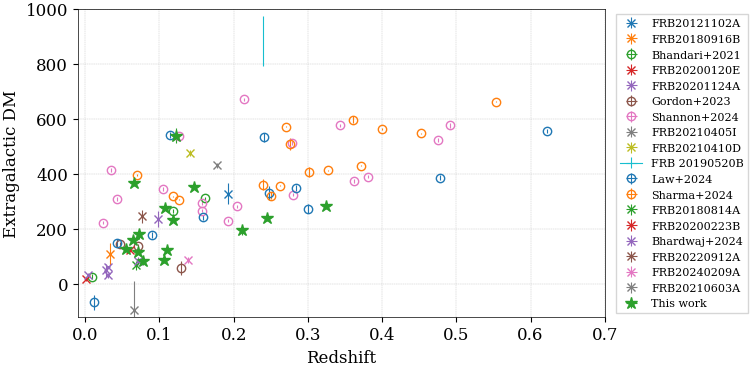

In [972]:
plt.style.use('/arc/home/calvin/kko_host_paper/plot_scripts/paper_sty.mplstyle')
z_max = 1.0
bhandari_keep = bhandari2021['primary_z_spec'] < z_max
bhardwaj_keep = bhardwaj2024['primary_z_spec'] < z_max
law_keep = law2024['primary_z_spec'] < z_max
leung_keep = (0 < final_zspec['primary_z_spec']) * (final_zspec['primary_P_Ox'] > 0.9)
michilli_keep = michilli2023['primary_z_spec'] < z_max
driessen_keep = driessen2024['primary_z_spec'] < z_max
caleb_keep = caleb2024['primary_z_spec'] < z_max
shannon_keep = (0 < shannon2024['primary_z_spec']) * (shannon2024['primary_z_spec'] < z_max)

plt.figure(figsize = (6.8,4))
plot_zdm(bhandari2021[bhandari2021.index == 'FRB20121102A'],z_max = z_max,label = 'FRB20121102A',ls='none',marker = 'x')
plot_zdm(bhandari2021[bhandari2021.index == 'FRB20180916B'],z_max = z_max,label = 'FRB20180916B',ls='none',marker = 'x')
plot_zdm(bhandari2021[bhandari_askap],z_max = z_max,label = 'Bhandari+2021',ls='none',marker = 'o',fillstyle = 'none')
plot_zdm(bhandari2021[bhandari2021.index == 'FRB20200120E'],z_max = z_max,label = 'FRB20200120E',ls='none',marker = 'x')
plot_zdm(bhandari2021[bhandari2021.index == 'FRB20201124A'],z_max = z_max,label = 'FRB20201124A',ls='none',marker = 'x')
plot_zdm(gordon2023,z_max = z_max,label = 'Gordon+2023',ls = 'none',marker = 'o',fillstyle = 'none')
plot_zdm(shannon2024,z_max = z_max,label = 'Shannon+2024',ls = 'none',marker = 'o',fillstyle = 'none')

plot_zdm(driessen2024,z_max = z_max,label = 'FRB20210405I',ls='none',marker = 'x')
plot_zdm(caleb2024,z_max = z_max,label = 'FRB20210410D',ls='none',marker = 'x')
plt.errorbar(x = [0.24],y = [903],xerr = [0],
             yerr = [[111],[72]],label = 'FRB 20190520B') 

plot_zdm(law2024,z_max = z_max,label = 'Law+2024',linestyle='none',marker = 'o',fillstyle = 'none')
plot_zdm(cs24,z_max = z_max,label = 'Sharma+2024',ls='none',marker = 'o',fillstyle = 'none')

plot_zdm(michilli2023,z_max = z_max,label = 'FRB20180814A',ls='none',marker = 'x')
plot_zdm(ibik2023,z_max = z_max,label = 'FRB20200223B',ls='none',marker = 'x')
plot_zdm(bhardwaj2024,z_max = z_max,label = 'Bhardwaj+2024',ls='none',marker = 'x')
plot_zdm(r117,z_max = z_max,label = 'FRB20220912A',ls='none',marker = 'x') # ACTUALLY THIS IS R117
plot_zdm(r155,z_max = z_max,label = 'FRB20240209A',ls='none',marker = 'x')
plot_zdm(cassanelli2023,z_max = z_max,label = 'FRB20210603A',ls='none',marker = 'x')
plot_zdm(final_zspec[leung_keep],z_max = z_max,label = 'This work',ls='none',marker = '*',markersize = 9,color = 'C2')

#label_above_dmh(final[leung_keep],0)
#label_above_dmh(bhandari2021[bhandari2021.index != 'FRB20121102A'],200)
#label_above_dmh(law2024[law_keep],50)
plt.ylim(-120,1000)
plt.xlim(-0.01,0.7)
plt.ylabel(r'Extragalactic DM')
plt.xlabel(f'Redshift')
#plt.plot(z_interp,dm_igm_interp,label = 'dm.igm.average_DM()',linestyle = '--',color = 'black')
plt.legend(loc = 'upper left',ncols = 1,bbox_to_anchor=(1.01, 1.0))
plt.savefig('/arc/home/calvin/kko_host_paper/figures/macquart.pdf',dpi = 100)

# Define redshift cut 

In [973]:
z_max = 0.2

# Make redshift and PATH cuts
in_chime = np.array([n in ['FRB20200120E','FRB20201124A','FRB20180916B'] for n in bhandari2021.index])
bhandari_askap = (bhandari2021['primary_z_spec'] < z_max) * ~in_chime * (bhandari2021.index != 'FRB20121102A')
bhandari_chime =  (bhandari2021['primary_z_spec'] < z_max) * in_chime
bhandari_keep = (bhandari2021['primary_z_spec'] < z_max)
bhardwaj_keep = bhardwaj2024['primary_z_spec'] < z_max
law_keep = law2024['primary_z_spec'] < z_max
leung_keep = (0 < final_zspec['primary_z_spec']) * (final_zspec['primary_P_Ox'] > 0.9) * (final_zspec['primary_z_spec'] < z_max)
michilli_keep = michilli2023['primary_z_spec'] < z_max
driessen_keep = driessen2024['primary_z_spec'] < z_max
cs24_keep = cs24['primary_z_spec'] < z_max
gordon_keep = gordon2023['primary_z_spec'] < z_max
shannon_keep = shannon2024['primary_z_spec'] < z_max

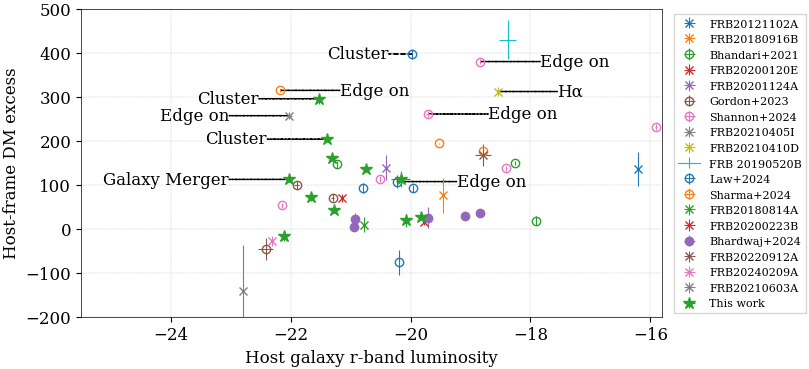

In [974]:
plt.style.use('/arc/home/calvin/kko_host_paper/plot_scripts/paper_sty.mplstyle')
z_max = 0.2
plt.figure(figsize = (7.5,4))
plot_survey(bhandari2021[bhandari2021.index == 'FRB20121102A'],z_max = z_max,label = 'FRB20121102A',ls='none',marker = 'x')
plot_survey(bhandari2021[bhandari2021.index == 'FRB20180916B'],z_max = z_max,label = 'FRB20180916B',ls='none',marker = 'x')
plot_survey(bhandari2021[bhandari_askap],z_max = z_max,label = 'Bhandari+2021',ls='none',marker = 'o',fillstyle = 'none')
plot_survey(bhandari2021[bhandari2021.index == 'FRB20200120E'],z_max = z_max,label = 'FRB20200120E',ls='none',marker = 'x')
plot_survey(bhandari2021[bhandari2021.index == 'FRB20201124A'],z_max = z_max,label = 'FRB20201124A',ls='none',marker = 'x')
plot_survey(gordon2023,z_max = z_max,label = 'Gordon+2023',ls = 'none',marker = 'o',fillstyle = 'none')
plot_survey(shannon2024,z_max = z_max,label = 'Shannon+2024',ls = 'none',marker = 'o',fillstyle = 'none')

plot_survey(driessen2024,z_max = z_max,label = 'FRB20210405I',ls='none',marker = 'x')
plot_survey(caleb2024,z_max = z_max,label = 'FRB20210410D',ls='none',marker = 'x')
plt.errorbar(22.1 - Planck18.distmod(z = 0.241).value,430,xerr = 0.14, # flux error bar
             yerr = 113 * 0.4,label = 'FRB 20190520B') # J-band extinction at 1.2 microns # R1 twin FRB 20190520

plot_survey(law2024,z_max = z_max,label = 'Law+2024',linestyle='none',marker = 'o',fillstyle = 'none')
plot_survey(cs24,z_max = z_max,label = 'Sharma+2024',ls='none',marker = 'o',fillstyle = 'none')

plot_survey(michilli2023,z_max = z_max,label = 'FRB20180814A',ls='none',marker = 'x')
plot_survey(ibik2023,z_max = z_max,label = 'FRB20200223B',ls='none',marker = 'x')
plot_survey(bhardwaj2024,z_max = z_max,label = 'Bhardwaj+2024',ls='none',marker = 'o')
plot_survey(r117,z_max = z_max,label = 'FRB20220912A',ls='none',marker = 'x') # ACTUALLY THIS IS R117
plot_survey(r155,z_max = z_max,label = 'FRB20240209A',ls='none',marker = 'x')
plot_survey(cassanelli2023,z_max = z_max,label = 'FRB20210603A',ls='none',marker = 'x')
plot_survey(final_zspec[leung_keep],z_max = z_max,label = 'This work',ls='none',marker = '*',markersize = 9,color = 'C2')

label_df(law2024,    xoffset = -0.4,name = 'FRB20220914A',s = 'Cluster',verticalalignment='center',horizontalalignment = 'right')
label_df(final_zspec,xoffset = -1,name = 'FRB20231206A',s = 'Cluster',verticalalignment='center',horizontalalignment='right') #FRB20231206A\n
label_df(final_zspec,xoffset = -1,name = 'FRB20230203A',s = 'Cluster',verticalalignment='center',horizontalalignment='right') #FRB20230203A\n NSC CLuster
label_df(final_zspec,xoffset = -1,name = 'FRB20231204A',s = 'Galaxy Merger',verticalalignment = 'center',horizontalalignment='right') #FRB20231204A\n

label_df(cassanelli2023,name = 'FRB20210603A', xoffset = -1, s = 'Edge on',verticalalignment = 'center',horizontalalignment = 'right')
label_df(shannon2024,xoffset = 1, name = 'FRB20240201A', s = 'Edge on',verticalalignment = 'center')
label_df(shannon2024,xoffset= 1, name = 'FRB20240310A', s = 'Edge on',verticalalignment = 'center')
label_df(law2024,xoffset = 1, name = 'FRB20220207C', s = 'Edge on', verticalalignment = 'center')
label_df(cs24,xoffset = 1, name = 'FRB20231120A',s = 'Edge on', verticalalignment = 'center')
label_df(caleb2024,name = 'FRB20210410D',xoffset = 1, s = r'Hα',horizontalalignment = 'left',verticalalignment='center')

#label_above_dmh(shannon2024[shannon_keep],150)
#label_above_dmh(cs24[cs24_keep],150)
#label_above_dmh(caleb2024,200)
#label_above_dmh(bhandari2021[bhandari2021.index != 'FRB20121102A'],200)
#label_above_dmh(law2024[law_keep],50)
plt.ylim(-200,500)
plt.xlim(-25.5,-15.8)
plt.xlabel('Host galaxy r-band luminosity')
plt.ylabel('Host-frame DM excess')
plt.legend(loc = 'upper left',ncols = 1,bbox_to_anchor=(1.01, 1.0))
plt.savefig('/arc/home/calvin/kko_host_paper/figures/dm_host.pdf',dpi = 100)

# Combined sample

In [975]:
all_chime = pd.concat((
    bhandari2021[bhandari_keep].loc[['FRB20180916B','FRB20200120E','FRB20201124A']],
    final_zspec[leung_keep],
    michilli2023[michilli_keep],
    ibik2023,
    bhardwaj2024,
    r67,
    r117,
    r155,)
)

_all_other = ((
    bhandari2021[bhandari_keep].loc[['FRB20121102A']],
    caleb2024,
    driessen2024[driessen_keep])
)
all_dsa = pd.concat((      
    cs24[cs24_keep * not_clusters(cs24) * not_edge_on(cs24)],
    law2024[law_keep * not_clusters(law2024) * not_edge_on(law2024)],
))

all_askap = pd.concat((
    bhandari2021[bhandari_keep].loc[['FRB20190608B','FRB20200430A','FRB20171020A','FRB20190608B']],
    gordon2023[gordon_keep * not_edge_on(gordon2023) * not_clusters(gordon2023)],
    shannon2024[shannon_keep * not_edge_on(shannon2024) * not_clusters(shannon2024)]
))
all_dsa =  all_dsa[not_edge_on(all_dsa) * not_clusters(all_dsa) * not_low_dm(all_dsa)]
all_chime= all_chime[not_edge_on(all_chime) * not_clusters(all_chime) * not_low_dm(all_chime)]
all_askap= all_askap[not_edge_on(all_askap) * not_clusters(all_askap) * not_low_dm(all_askap)]
all_clean = pd.concat((all_dsa,all_chime,all_askap))

In [976]:
len(all_dsa),len(all_askap),len(all_chime),len(all_clean)

(4, 13, 17, 34)

In [977]:
parent = pd.concat((
    #driessen2024[driessen_keep]
    caleb2024[caleb_keep],
    bhandari2021[bhandari_keep * (bhandari2021.index != 'FRB20121102A')],
    gordon2023[gordon_keep],
    shannon2024[shannon_keep * (shannon2024.index != 'FRB20181112A')],
    law2024[law_keep],
    cs24[cs24_keep],
    michilli2023[michilli_keep],
    ibik2023,
    bhardwaj2024,
    cassanelli2023,
    final_zspec[leung_keep],
        ))
parent = parent[parent['primary_z_spec'] < 0.15]
remove_clusters = parent[not_clusters(parent)]
remove_clusters_lowdm = parent[not_clusters(parent) * not_low_dm(parent)]
remove_clusters_lowdm_edgeon = parent[not_clusters(parent) * not_low_dm(parent) * not_edge_on(parent)]

print(len(parent),len(remove_clusters),len(remove_clusters_lowdm),len(remove_clusters_lowdm_edgeon))

40 35 29 26


In [978]:
import numpy as np
from scipy.optimize import minimize

def mvsk(dm,dm_err):
    """
    Maximum-likelihood estimation of the mean, standard deviation, skewness, and kurtosis 
    for data with Gaussian uncertainties.

    Parameters:
    - data: array of observed data points
    - data_err: array of uncertainties associated with each data point

    Returns:
    - MLEs: mean, standard deviation, skewness, and kurtosis
    - Uncertainties: uncertainties in each parameter
    """
    def neg_log_likelihood(params):
        mu, sigma2 = params
        # Avoid log(0) by ensuring sigma > 0
        if sigma2 <= 0:
            return np.inf
        # Compute the negative log-likelihood
        nll = np.sum(np.log(sigma2 + dm_err**2) + 
                                  0.5 * ((dm - mu)** 2) / (dm_err**2 + sigma2))
        return nll

    def weighted_mean(data, data_err):
        weights = 1 / (sigma_mle**2 + data_err**2)
        return np.sum(weights * data) / np.sum(weights)
    
    def weighted_variance(data, data_err, mu_mle, sigma_mle):
        weights = 1 / (sigma_mle**2 + data_err**2)
        w_sum = np.sum(weights)
        variance_mle = np.sum(weights * ((data - mu_mle) / sigma_mle)**2) / w_sum
        return variance_mle, weights
    
    def weighted_skewness(data, data_err, mu_mle, sigma_mle):
        """Weighted estimator for skewness using inverse variance weighting."""
        weights = 1 / (sigma_mle**2 + data_err**2)
        w_sum = np.sum(weights)
        m4 = np.sum(weights * ((data - mu_mle) / sigma_mle)**4) / np.sum(weights)
        m3 = np.sum(weights * ((data - mu_mle) / sigma_mle)**3) / np.sum(weights)
        m2 = np.sum(weights * ((data - mu_mle) / sigma_mle)**2) / np.sum(weights)
        n = len(data)
        nval = ((n - 1.0) * n)**0.5 / (n - 2.0) * m3 / m2**1.5
        return nval, weights

    def weighted_kurtosis(data, data_err, mu_mle, sigma_mle):
        """Weighted estimator for kurtosis using inverse variance weighting."""
        weights = 1 / (sigma_mle**2 + data_err**2)
        w_sum = np.sum(weights)
        m4 = np.sum(weights * ((data - mu_mle) / sigma_mle)**4) / np.sum(weights)
        m3 = np.sum(weights * ((data - mu_mle) / sigma_mle)**3) / np.sum(weights)
        m2 = np.sum(weights * ((data - mu_mle) / sigma_mle)**2) / np.sum(weights)
        n = len(data)
        nval = 1.0/(n-2)/(n-3) * ((n**2-1.0)*m4/m2**2.0 - 3*(n-1)**2.0)
        return nval - 3, weights

    def propagate_error(data, data_err, mu_mle, sigma_mle, power):
        """
        Propagate uncertainties for skewness and kurtosis using Gaussian error propagation.

        Parameters:
        - data: data points
        - data_err: uncertainties of the data points
        - weights: inverse variance weights (1 / (sigma_mle**2 + data_err**2))
        - mu_mle: MLE of the mean
        - sigma_mle: MLE of the standard deviation
        - power: power of the moment (3 for skewness, 4 for kurtosis)

        Returns:
        - propagated uncertainty of the moment
        """
        weights = (data_err**2 + sigma_mle**2)**-1
        w_sum = np.sum(weights)  # Sum of weights

        # Calculate normalized deviations
        moment = (data - mu_mle) / sigma_mle

        # Compute the moments raised to the specified power
        moment_power = moment**power

        # Compute the partial derivatives of the moment with respect to each data point
        # Partial derivative should consider how moment_power changes with each data point
        # Includes a factor of 1 / sigma_mle due to normalization and power-1
        partials = weights * power * (moment**(power - 1.0)) / (w_sum * sigma_mle)

        # Now propagate the uncertainty for each data point using Gaussian error propagation
        propagated_variance = np.sum((partials * data_err)**2)

        return np.sqrt(propagated_variance)
    assert len(dm) == len(dm_err)
    # Define the negative log-likelihood function for a normal distribution

    # Initial guesses for mu and sigma
    print('dddddd',np.std(dm)**2)
    initial_guess = [np.mean(dm), np.std(dm)**2]
    
    # Minimize the negative log-likelihood
    result = minimize(neg_log_likelihood, initial_guess,  
                       jac = '2-point')
    
    mu_mle = result.x[0]
    sigma2_mle = result.x[1]
    mu_err,sigma2_err = np.sqrt(np.diag(result.hess_inv))
    sigma_err = sigma2_err / (2 * np.sqrt(sigma2_mle))
    sigma_mle = np.sqrt(sigma2_mle)
    ### OK NOW WE HAVE GAUSSIAN PART RIGHT...do higher orders
    
    # Compute weighted skewness and kurtosis
    mean_mle, weights = weighted_mean(dm, dm_err)
    nvar_mle, weights = weighted_variance(dm, dm_err, mu_mle, np.sqrt(sigma2_mle))
    print('nvar_mle (should be close to 1?):',nvar_mle)
    skewness_mle, weights = weighted_skewness(dm, dm_err, mu_mle, np.sqrt(sigma2_mle))
    kurtosis_mle, _ = weighted_kurtosis(dm, dm_err, mu_mle, np.sqrt(sigma2_mle))

    # Compute uncertainties for skewness and kurtosis using error propagation
    skewness_err = propagate_error(dm, dm_err, mu_mle, np.sqrt(sigma2_mle), 3)
    kurtosis_err = propagate_error(dm, dm_err, mu_mle, np.sqrt(sigma2_mle), 4)

    # Return the MLEs and their uncertainties
    mle_estimates = (mu_mle, np.sqrt(sigma2_mle), skewness_mle, kurtosis_mle)

    uncertainties = (mu_err, sigma_err, skewness_err, kurtosis_err)

    return [[mu_mle, mu_err], [sigma_mle, sigma_err], [skewness_mle, skewness_err], [kurtosis_mle,kurtosis_err]]

In [979]:
from random import sample

In [980]:
def mvsk_bootstrap(dm,dm_err):
    if len(dm) > 100 and len(dm) < 1000:
        realizations = 1000
    if len(dm) < 100:
        realizations = 1000
    """Bootstrap realizations over zeroth axis, data over axis 1."""
    assert len(dm) == len(dm_err)
    n = len(dm)
    weights = 1 / (np.std(dm)**2 + dm_err**2) #use the un-weighted standard deviation, just to calculate the weight which we use later on
    iichoices = np.random.randint(low = 0, high = len(dm),size = 1000 * len(dm))

    _dm = dm[iichoices].reshape((1000,len(dm))) # sample with replacement
    _dm_err = dm_err[iichoices].reshape((1000,len(dm))) # sample with replacement
    _weights= weights[iichoices].reshape((1000,len(dm))) # sample with replacement
    w_sum = np.sum(_weights,axis = 1)
    m1 = np.sum(_weights * _dm,axis = 1) / np.sum(_weights,axis = 1)
    m2 = np.sum(_weights * (_dm - m1[:,None])**2,axis = 1) / np.sum(_weights,axis = 1)
    m3 = np.sum(_weights * (_dm - m1[:,None])**3,axis = 1) / np.sum(_weights,axis = 1)
    m4 = np.sum(_weights * (_dm - m1[:,None])**4,axis = 1) / np.sum(_weights,axis = 1)

    nval_variance = n / (n-1) * m2
    nval_skew = ((n - 1.0) * n)**0.5 / (n - 2.0) * m3 / m2**1.5
    nval_kurt = 1.0/(n-2)/(n-3) * ((n**2-1.0)*m4/m2**2.0 - 3*(n-1)**2.0)
    nval_kurt -= 3
    nval_kurt - 3, weights
    return [[np.mean(m1), np.std(m1)], [np.mean(np.sqrt(nval_variance)),np.std(np.sqrt(nval_variance))], [np.mean(nval_skew),np.std(nval_skew)], [np.mean(nval_kurt),np.std(nval_kurt)]]



In [981]:
dm_debug_err = np.ones(10000)
dm_debug = np.exp(np.random.randn(10000))
bs_answer = mvsk_bootstrap(dm_debug,dm_debug_err)
mm = np.mean(dm_debug)
ss = np.std(dm_debug)
gg = skew(dm_debug,bias = False)
kk = kurtosis(dm_debug,bias = False)
print(mm,ss,gg,kk)
print(bs_answer)

1.6257768104552748 2.0396044736660004 4.454739387734652 35.007767800918465
[[1.62570669787762, 0.020740523010571405], [2.0374051964251776, 0.06258857491147825], [4.414586629606643, 0.34995863673588085], [31.183133196181334, 6.419113293337133]]


answer from scipy: 1.6391376854443271 2.0413534226280645 4.197397897308512 32.3968914787048
bs answer [[1.6384927173614754, 0.019960497957469632], [2.03958098929927, 0.05908170236152771], [4.171663916253726, 0.455748127646415], [28.79838734007999, 10.097784629017106]]
Mean (non-logged): 1.6487 ± 0.0023; median = 1.0000
std (non-logged): 2.1612 ± 0.0060
Skewness: 6.1849 + 0.0169 - 0.0169
Kurtosis: 110.9364 + 0.7695 - 0.7635
test error prop mvsk_lognormal [[1.6487212707001282, 0.0023316439815971243], [2.1611974158950877, 0.005984060107741525], [6.184877138632554, 0.016910797981889214], [110.93639217631153, 0.766489305784475], 'test lognormal 0 1']
fancy science function [1.638895980467695, 2.040143356513408, 4.165811947777549, 28.660216877123453]


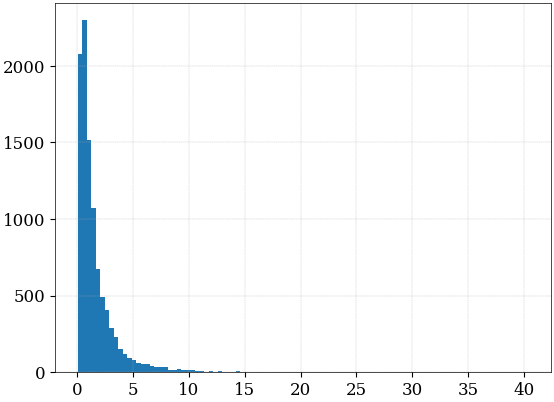

In [982]:
dm_debug_err = np.ones(10000)
dm_debug = np.exp(np.random.randn(10000))
plt.figure()
plt.hist(dm_debug,bins = 100)
mm = np.mean(dm_debug)
ss = np.std(dm_debug)
gg = skew(dm_debug,bias = False)
kk = kurtosis(dm_debug,bias = False)
#gg = np.mean(dm_debug**3) / np.mean(np.ones(1000)) / ss**3
#kk = (np.mean(dm_debug**4) / (ss**4 * np.mean(np.ones(1000)))) - 3
print('answer from scipy:',mm,ss,gg,kk)
bs_answer = mvsk_bootstrap(dm_debug,dm_debug_err)
print('bs answer',bs_answer)
print('test error prop mvsk_lognormal',mvsk_numerical_from_lognormal(m = 0,w = 1, 
                                                      delta_m_plus = 0.001,
                                                      delta_m_minus = 0.001,
                                                      delta_w_plus = 0.001,delta_w_minus = 0.001,label = 'test lognormal 0 1'))
fit_answers = mvsk_bootstrap(dm_debug,dm_debug_err)
print('fancy science function',[f[0] for f in fit_answers])

In [983]:
import numpy as np
from scipy.optimize import minimize
def sigma_igm_walker2024(z):
    return np.interp(x = z,xp = [0,0.1,0.2], fp = [0, 63.30, 104.84])

import numpy as np
import matplotlib.pyplot as plt
def analyze_sample(df,label,diagnostic = None,sigma_igm = 'walker'):
    dm = df['DM_host_restframe']
    if sigma_igm == "walker":
        sig_igm = sigma_igm_walker2024(df['primary_z_spec'])**2 
        sig_igm = 80
    elif sigma_igm == "none":
        sig_igm = 0
    dm_err = np.sqrt(
        10**2 + (df['DM_NE2001'] * 0.15)**2 + sig_igm**2
        )
    isfinite = np.isfinite(dm.values) * np.isfinite(dm_err.values) * (dm_err.values > 0)
    mvsk_answers =  mvsk_bootstrap(dm.values[isfinite], dm_err.values[isfinite])
    [[mu,mu_e],[sig,sig_e],[gam,gam_e],[kurt,kurt_e]] = mvsk_answers
    sample_size = len(df['DM_host_restframe'])
    label = label + f" ({sample_size:.0f})"
    print(f"{label}: $\mu = {mu:.2f} \pm {mu_e:.2f}$, $\sigma={sig:.2f} \pm {sig_e:.2f}$, $\gamma_1={gam:.2f} \pm {gam_e:.2f}$,$\gamma_2={kurt:.2f} \pm {kurt_e:.2f}$ (N = {sample_size})")
    if diagnostic:
        bins = np.linspace(np.min(df['DM_host_restframe']),np.max(df['DM_host_restframe']),num = max(10,int(sample_size / 8)))
        plt.figure()
        plt.hist(df['DM_host_restframe'],bins=bins)
        dumb_mean = np.nanmean(df['DM_host_restframe'])
        dumb_std = np.nanstd(df['DM_host_restframe'])
        plt.axvline(dumb_mean,label = f'{dumb_mean:.1f}')
        plt.axvline(dumb_std,label = f'{dumb_std:.1f}')
        plt.legend()
        plt.title(label)
    return mvsk_answers,label
#analyze_sample(no_clusters_no_low_dm[np.abs(no_clusters_no_low_dm['gal_b']) > 10],label = 'No clusters, no low-DM, |b| > 10')

# Global fits

In [986]:
def mvsk_numerical_from_lognormal(m,delta_m_plus,delta_m_minus,w,delta_w_plus,delta_w_minus,label):
    """mu is in natural DM units. mu_err is also. sigma is in log units (i.e. does not matter log10 or ln). sigma_merr and sigma_perr are also in log units."""

    # Moments formulas
    def mu_real(m, w):
        return np.exp(m + (w**2) / 2)

    def var_real(m, w):
        return (np.exp(w**2) - 1) * np.exp(2 * m + w**2)

    def skewness(w):
        return (np.exp(w**2) + 2) * np.sqrt(np.exp(w**2) - 1)

    def kurtosis(w):
        return np.exp(4 * w**2) + 2 * np.exp(3 * w**2) + 3 * np.exp(2 * w**2) - 6

    # Derivatives of the moments with respect to m and w
    def dmu_dm(m, w):
        return mu_real(m, w)

    def dvar_dm(m, w):
        return 2 * np.exp(2*m+w**2) * (np.exp(w**2) - 1)
        
    def dmu_dw(m, w):
        return mu_real(m, w) * w
    
    def dvar_dw(m, w):
        return 2 * np.exp(2*m+w**2) * (2 * np.exp(w**2) - 1) * w

    def dskew_dw(w):
        ew2 = np.exp(w**2)
        return w * np.exp(2 + w**2) * (-2 + 3 * ew2) / (np.sqrt(ew2 - 1))

    def dkurt_dw(w):
        ew2 = np.exp(w**2)
        return 4 * w * ew2**2 * (3 + 3 * ew2 + 2 * ew2**2)

    # Error propagation using Gaussian propagation formula
    sigma_m = (delta_m_plus + delta_m_minus) / 2
    sigma_w = (delta_w_plus + delta_w_minus) / 2
    mu_value = mu_real(m, w)
    mu_err = np.sqrt((dmu_dm(m, w) * sigma_m)**2 + (dmu_dw(m, w) * sigma_w)**2)

    var_value = var_real(m, w)
    var_err = np.sqrt((dvar_dm(m, w) * sigma_m)**2 + (dvar_dw(m, w) * sigma_w)**2)
    std_value = np.sqrt(var_value)
    std_err = var_err / (2 * np.sqrt(var_value))

    # For skew and kurtosis do the derivatives numerically
    skew_plus = skewness(w + delta_w_plus)
    skew_value = skewness(w)
    skew_minus = skewness(w - delta_w_minus)
    skew_err = 0.5 * (skew_plus - skew_minus)
    
    kurt_plus = kurtosis(w + delta_w_plus)
    kurt_value = kurtosis(w)
    kurt_minus = kurtosis(w - delta_w_minus)
    kurt_err = 0.5 * (kurt_plus - kurt_minus)
    
    # Calculating the values of the moments in real space
    print(f"Mean (non-logged): {mu_value:.4f} ± {mu_err:.4f}; median = {np.exp(m):.4f}")
    print(f"std (non-logged): {std_value:.4f} ± {std_err:.4f}")
    print(f"Skewness: {skew_value:.4f} + {skew_plus - skew_value:.4f} - {skew_value - skew_minus:.4f}")
    print(f"Kurtosis: {kurt_value:.4f} + {kurt_plus - kurt_value:.4f} - {kurt_value - kurt_minus:.4f}")
    return [[mu_value,mu_err],[std_value,std_err],[skew_value,skew_err],[kurt_value,kurt_err],label]


In [987]:

def mvsk_lognormal(m,delta_m_plus,delta_m_minus,w,delta_w_plus,delta_w_minus,label):
    """mu is in natural DM units. mu_err is also. sigma is in log units (i.e. does not matter log10 or ln). sigma_merr and sigma_perr are also in log units."""

    sigma_m = (delta_m_plus + delta_m_minus) / 2
    sigma_w = (delta_w_plus + delta_w_minus) / 2

    # Moments formulas
    def mu_real(m, w):
        return np.exp(m + (w**2) / 2)

    def var_real(m, w):
        return (np.exp(w**2) - 1) * np.exp(2 * m + w**2)

    def skewness(w):
        return (np.exp(w**2) + 2) * np.sqrt(np.exp(w**2) - 1)

    def kurtosis(w):
        return np.exp(4 * w**2) + 2 * np.exp(3 * w**2) + 3 * np.exp(2 * w**2) - 6
    dmu_dm = (mu_real(m + sigma_m,w) - mu_real(m - sigma_m,w)) / sigma_m / 2
    dmu_dw = (mu_real(m,w + sigma_w) - mu_real(m,w - sigma_w)) / sigma_w / 2
    dvar_dm = (var_real(m + sigma_m,w) - var_real(m - sigma_m,w)) / sigma_m / 2
    dvar_dw = (var_real(m,w + sigma_w) - var_real(m,w - sigma_w)) / sigma_w / 2
    
    # Error propagation using Gaussian propagation formula
    mu_err = np.sqrt((dmu_dm * sigma_m)**2 + (dmu_dw * sigma_w)**2)
    var_err = np.sqrt((dvar_dm * sigma_m)**2 + (dvar_dw * sigma_w)**2)
    skew_err = np.abs(dskew_dw(w)) * sigma_w
    kurt_err = np.abs(dkurt_dw(w)) * sigma_w

    # Calculating the values of the moments in real space
    mu_value = mu_real(m, w)
    var_value = var_real(m, w)
    skew_value = skewness(w)
    kurt_value = kurtosis(w)
    std_value = np.sqrt(var_value)
    std_err = var_err / (2 * np.sqrt(var_value))
    print(label)
    print(var_value,var_err,sigma_m,sigma_w)
    # Output the results
    print(f"Mean (non-logged): {mu_value:.4f} ± {mu_err:.4f}; median = {np.exp(m):.4f}")
    print(f"std (non-logged): {std_value:.4f} ± {std_err:.4f}")
    print(f"Skewness: {skew_value:.4f} ± {skew_err:.4f}")
    print(f"Kurtosis: {kurt_value:.4f} ± {kurt_err:.4f}")

    return [[mu_value,mu_err],[std_value,std_err],[skew_value,skew_err],[kurt_value,kurt_err],label]

# James 2021 james: (65, 65+95, 65 - 25,0.9,0.9+0.9,0.9-0.6); log10(130); log10(130+66);log10(130-48)
james_vsk = mvsk_numerical_from_lognormal(m = np.log(130),delta_m_plus = np.log((130 + 66) / 130), delta_m_minus = np.log(130 / (130 - 48)),
                                    w = 0.53, delta_w_plus = 0.15, delta_w_minus = 0.11,label = 'James+2021')

# Shin 2023 shin = (84, 69, 49,0.41,0.41+0.21,0.41-0.20) (mu_host= 1.93, 0.26,-0.38)
shin_vsk = mvsk_numerical_from_lognormal(m = np.log(84),delta_m_plus = np.log((84 + 69) / 84), delta_m_minus = np.log(84 / (84 - 49)),
                          w = 0.4 / np.log10(2.718), 
                          delta_w_plus = 0.21 / np.log10(2.718), 
                          delta_w_minus = 0.20 / np.log10(2.718),
                          label = 'Shin+2023'
                         )
#correponds to 130 + 25 -23
connor_vsk = mvsk_numerical_from_lognormal(m = 4.9, delta_m_plus = 0.18,
                            delta_m_minus=  0.2,
                            w = 0.56, delta_w_plus = 0.16, 
                            delta_w_minus = 0.14,
                            label = 'Connor+2024')

Mean (non-logged): 149.6029 ± 65.9916; median = 130.0000
std (non-logged): 85.1977 ± 47.6272
Skewness: 1.8932 + 0.8578 - 0.4908
Kurtosis: 6.9826 + 8.9460 - 3.2933
Mean (non-logged): 128.3880 ± 109.9246; median = 84.0000
std (non-logged): 148.4030 ± 208.4183
Skewness: 5.0121 + 17.8697 - 3.4389
Kurtosis: 65.6521 + 3506.6539 - 60.9515
Mean (non-logged): 157.0870 ± 32.6333; median = 134.2898
std (non-logged): 95.3380 ± 41.8788
Skewness: 2.0443 + 0.9883 - 0.6419
Kurtosis: 8.2469 + 11.6391 - 4.5575


# 80 units

-20.758359247046624

All excl. G&C,LowDM,EdgeOn,Non Luminous (12): $\mu = 122.50 \pm 27.50$, $\sigma=90.52 \pm 15.99$, $\gamma_1=0.41 \pm 0.56$,$\gamma_2=-3.46 \pm 1.19$ (N = 12)
All excl. G&C,LowDM,EdgeOn,Luminous (13): $\mu = 96.80 \pm 28.19$, $\sigma=97.98 \pm 20.52$, $\gamma_1=0.66 \pm 0.54$,$\gamma_2=-2.72 \pm 1.50$ (N = 13)
All excl. G&C,LowDM,EdgeOn (26): $\mu = 117.95 \pm 22.78$, $\sigma=105.24 \pm 15.38$, $\gamma_1=0.69 \pm 0.36$,$\gamma_2=-2.97 \pm 0.96$ (N = 26)
All excl. G&C,LowDM,EdgeOn (26): $\mu = 117.89 \pm 20.45$, $\sigma=106.04 \pm 14.68$, $\gamma_1=0.69 \pm 0.35$,$\gamma_2=-3.00 \pm 0.88$ (N = 26)
All excl. G&C,LowDM (29): $\mu = 132.30 \pm 21.48$, $\sigma=113.30 \pm 13.87$, $\gamma_1=0.64 \pm 0.30$,$\gamma_2=-3.26 \pm 0.75$ (N = 29)
All excl. G&C (35): $\mu = 109.75 \pm 20.44$, $\sigma=113.98 \pm 14.19$, $\gamma_1=0.81 \pm 0.32$,$\gamma_2=-2.89 \pm 0.93$ (N = 35)
CHIME excl. G&C,LowDM,EdgeOn (17): $\mu = 70.12 \pm 15.77$, $\sigma=62.18 \pm 6.94$, $\gamma_1=0.13 \pm 0.45$,$\gamma_2=-4.14

/tmp/ipykernel_90896/734431133.py:22: RuntimeWarning: invalid value encountered in divide
  nval_skew = ((n - 1.0) * n)**0.5 / (n - 2.0) * m3 / m2**1.5
/tmp/ipykernel_90896/734431133.py:23: RuntimeWarning: invalid value encountered in divide
  nval_kurt = 1.0/(n-2)/(n-3) * ((n**2-1.0)*m4/m2**2.0 - 3*(n-1)**2.0)


DSA110 excl. G&C,LowDM,EdgeOn (4): $\mu = 192.43 \pm 40.91$, $\sigma=72.62 \pm 28.61$, $\gamma_1=nan \pm nan$,$\gamma_2=nan \pm nan$ (N = 4)
ASKAP excl. G&C,LowDM,EdgeOn (13): $\mu = 130.46 \pm 28.17$, $\sigma=96.44 \pm 23.66$, $\gamma_1=0.41 \pm 0.80$,$\gamma_2=-1.99 \pm 1.67$ (N = 13)
All (40): $\mu = 124.36 \pm 19.46$, $\sigma=121.06 \pm 12.38$, $\gamma_1=0.71 \pm 0.27$,$\gamma_2=-3.21 \pm 0.70$ (N = 40)


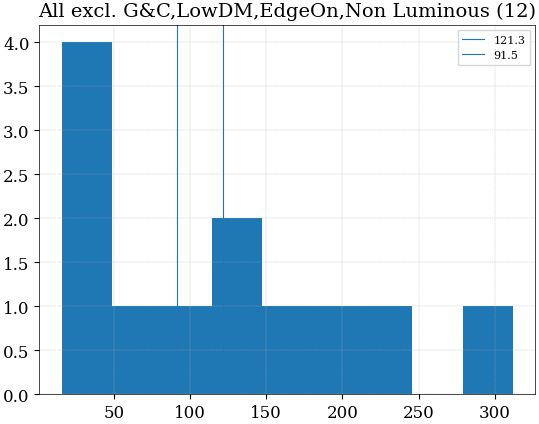

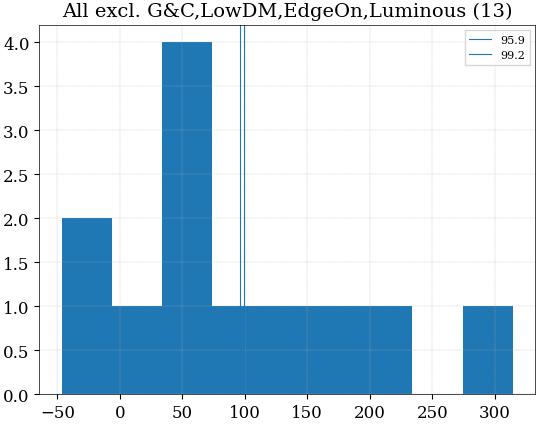

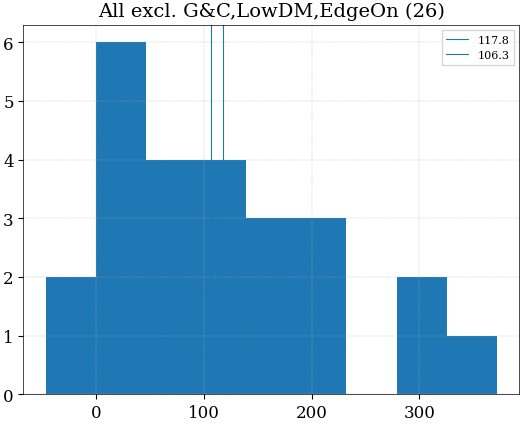

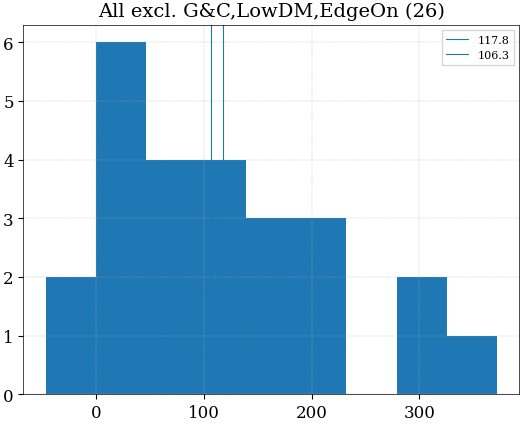

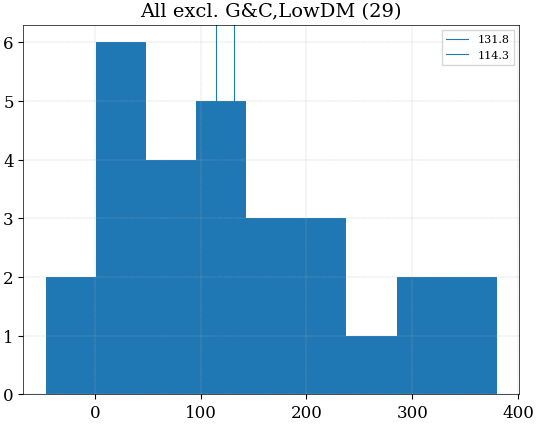

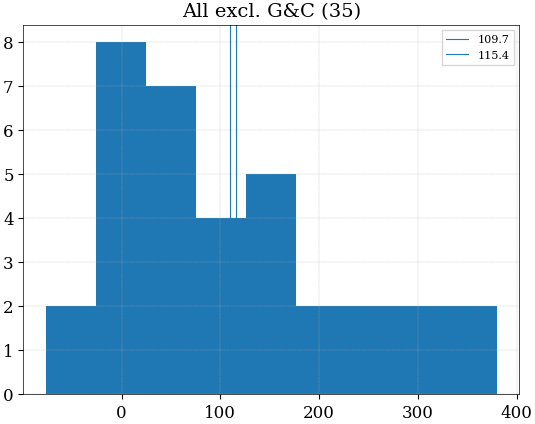

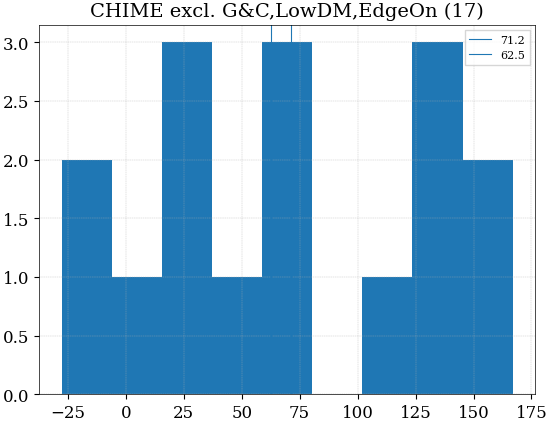

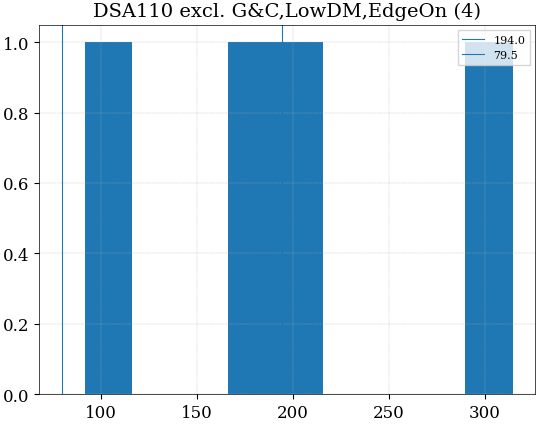

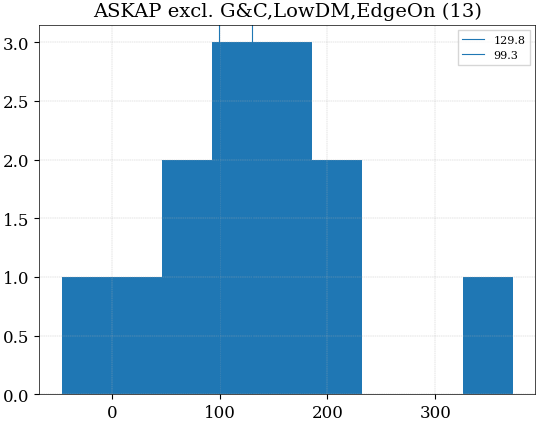

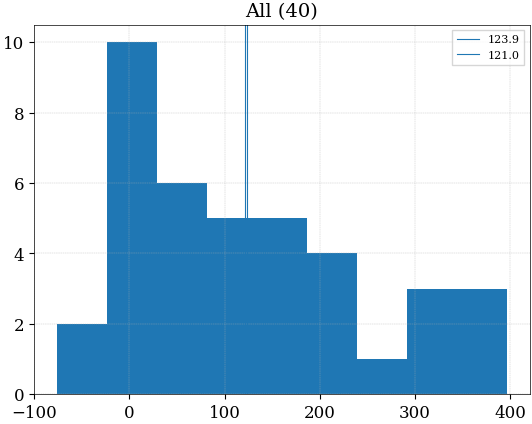

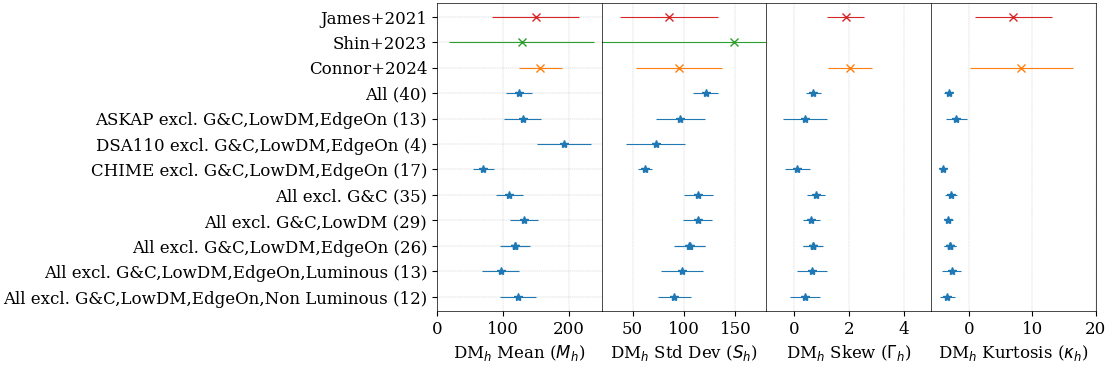

In [990]:
ds_compilation = []
M_r_cutoff = np.nanmedian(remove_clusters_lowdm_edgeon['M_r'])
lum = (M_r_cutoff < remove_clusters_lowdm_edgeon['M_r']) * remove_clusters_lowdm_edgeon['M_r'] > -17
nonlum = (M_r_cutoff > remove_clusters_lowdm_edgeon['M_r']) * remove_clusters_lowdm_edgeon['M_r'] > -17
ds_compilation.append(analyze_sample(remove_clusters_lowdm_edgeon[nonlum],diagnostic = True, 
                label = 'All excl. G&C,LowDM,EdgeOn,Non Luminous'))
ds_compilation.append(analyze_sample(remove_clusters_lowdm_edgeon[lum],diagnostic = True, 
                label = 'All excl. G&C,LowDM,EdgeOn,Luminous'))
ds_compilation.append(analyze_sample(remove_clusters_lowdm_edgeon,diagnostic = True,
               label = 'All excl. G&C,LowDM,EdgeOn',sigma_igm='walker'))
ds_compilation.append(analyze_sample(remove_clusters_lowdm_edgeon,diagnostic = True,
               label = 'All excl. G&C,LowDM,EdgeOn',sigma_igm='walker'))
ds_compilation.append(analyze_sample(remove_clusters_lowdm,diagnostic = True,
               label = 'All excl. G&C,LowDM',sigma_igm='walker'))
ds_compilation.append(analyze_sample(remove_clusters,diagnostic = True,
               label = 'All excl. G&C',sigma_igm='walker'))
ds_compilation.append(analyze_sample(all_chime,diagnostic = True,
               label = 'CHIME excl. G&C,LowDM,EdgeOn',sigma_igm='walker'))
ds_compilation.append(analyze_sample(all_dsa,diagnostic = True,
               label = 'DSA110 excl. G&C,LowDM,EdgeOn',sigma_igm='walker'))
ds_compilation.append(analyze_sample(all_askap,diagnostic = True,
               label = 'ASKAP excl. G&C,LowDM,EdgeOn',sigma_igm='walker'))
ds_compilation.append(analyze_sample(parent,diagnostic = True,
               label = 'All',sigma_igm='walker'))

f,axs = plt.subplots(ncols = 4, nrows = 1,figsize = (8.5,4))
f.subplots_adjust(wspace=0)

for ii in [0,1,2,3]: # get each moment
    axs[ii].errorbar(x =[d[0][ii][0] for d in ds_compilation], 
                 xerr = [d[0][ii][1] for d in ds_compilation],
                    y = [d[1] for d in ds_compilation],linestyle = 'none',marker = '*')

    axs[ii].errorbar(x = [connor_vsk[ii][0]],
                 xerr = [connor_vsk[ii][1]],
                     y = ['Connor+2024'],marker = 'x')
    if ii < 2:
        axs[ii].errorbar(x = [shin_vsk[ii][0]],
                     xerr = [shin_vsk[ii][1]],
                         y = ['Shin+2023'],marker = 'x')
    else:
        axs[ii].errorbar(x = [-999],xerr = [1],y = ['Shin+2023'],marker = 'x') # hide Kaitlyn measurements
    axs[ii].errorbar(x = [james_vsk[ii][0]],
                 xerr = [james_vsk[ii][1]],
                     y = ['James+2021'],marker = 'x')

    
axs[1].get_yaxis().set_visible(False)
axs[2].get_yaxis().set_visible(False)
axs[3].get_yaxis().set_visible(False)

axs[0].set_xlabel(r'DM$_h$ Mean ($M_h$)')
axs[1].set_xlabel(r'DM$_h$ Std Dev ($S_h$)') 
axs[2].set_xlabel(r'DM$_h$ Skew ($\Gamma_h$)') 
axs[3].set_xlabel(r'DM$_h$ Kurtosis ($\kappa_h$)') 

axs[0].set_xlim(0,250)
axs[1].set_xlim(20,180)
axs[2].set_xlim(-1,5)
axs[3].set_xlim(-6,20)
plt.savefig('/arc/home/calvin/kko_host_paper/figures/mvsk.pdf',dpi = 110)

In [994]:
final['primary_id']

'DECaL 9907733628324412'

In [999]:
decals_fields = 0
ps1 = 0
total = 0
for ff in final['primary_id'].values:

    if type(ff) is str:
        total += 1
        if ff[0] == 'D':
            decals_fields += 1
        if ff[0] == 'P':
            ps1 += 1
    else:
        print(ff,'fail')
print(decals_fields,ps1,total)

nan fail
nan fail
55 26 81


# 0 units

All -Clusters,LowDM,EdgeOn (26): $\mu = 109.81 \pm 19.60$, $\sigma=98.26 \pm 16.09$, $\gamma_1=0.75 \pm 0.42$,$\gamma_2=-2.52 \pm 1.15$ (N = 26)
All -Clusters,LowDM (29): $\mu = 131.30 \pm 21.23$, $\sigma=113.34 \pm 13.93$, $\gamma_1=0.66 \pm 0.32$,$\gamma_2=-3.18 \pm 0.84$ (N = 29)
All -Clusters (35): $\mu = 110.75 \pm 19.66$, $\sigma=114.77 \pm 13.58$, $\gamma_1=0.79 \pm 0.30$,$\gamma_2=-2.97 \pm 0.80$ (N = 35)
CHIME -Clusters,LowDM,EdgeOn (17): $\mu = 70.71 \pm 15.87$, $\sigma=62.56 \pm 7.00$, $\gamma_1=0.08 \pm 0.46$,$\gamma_2=-4.13 \pm 0.65$ (N = 17)
DSA110 -Clusters,LowDM,EdgeOn (4): $\mu = 143.30 \pm 22.15$, $\sigma=41.39 \pm 13.54$, $\gamma_1=nan \pm nan$,$\gamma_2=nan \pm nan$ (N = 4)
ASKAP -Clusters,LowDM,EdgeOn (13): $\mu = 129.70 \pm 26.95$, $\sigma=96.89 \pm 24.08$, $\gamma_1=0.39 \pm 0.81$,$\gamma_2=-1.99 \pm 1.63$ (N = 13)


/tmp/ipykernel_90896/734431133.py:22: RuntimeWarning: invalid value encountered in divide
  nval_skew = ((n - 1.0) * n)**0.5 / (n - 2.0) * m3 / m2**1.5
/tmp/ipykernel_90896/734431133.py:23: RuntimeWarning: invalid value encountered in divide
  nval_kurt = 1.0/(n-2)/(n-3) * ((n**2-1.0)*m4/m2**2.0 - 3*(n-1)**2.0)


Parent (40): $\mu = 123.81 \pm 19.98$, $\sigma=120.37 \pm 12.34$, $\gamma_1=0.71 \pm 0.27$,$\gamma_2=-3.21 \pm 0.69$ (N = 40)


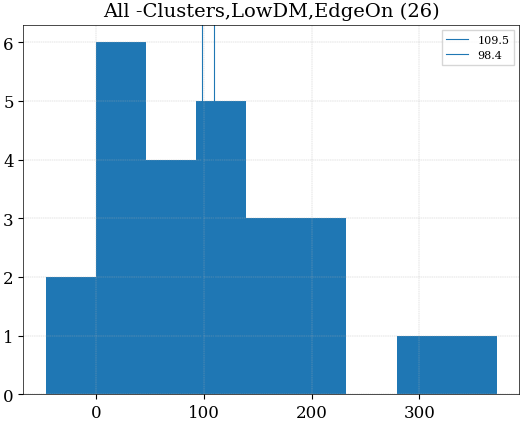

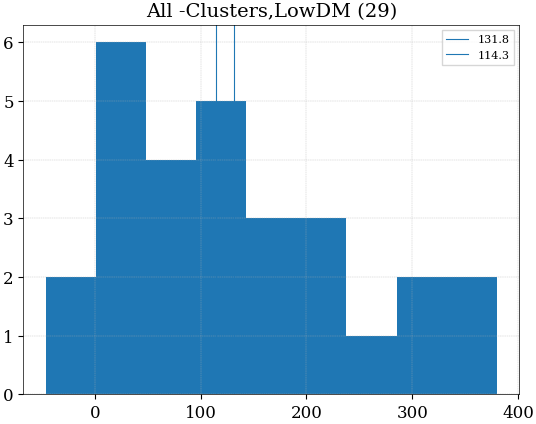

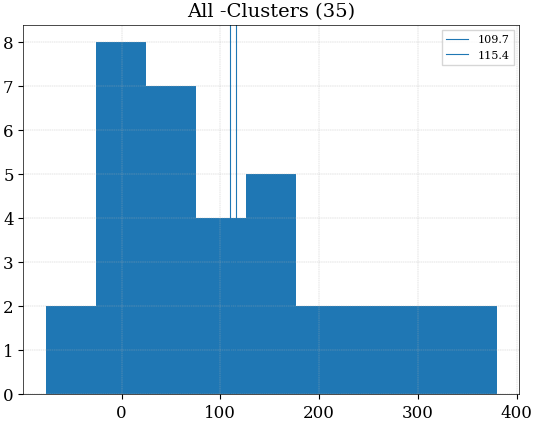

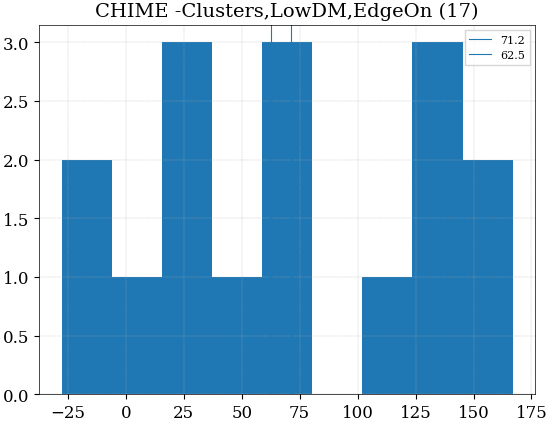

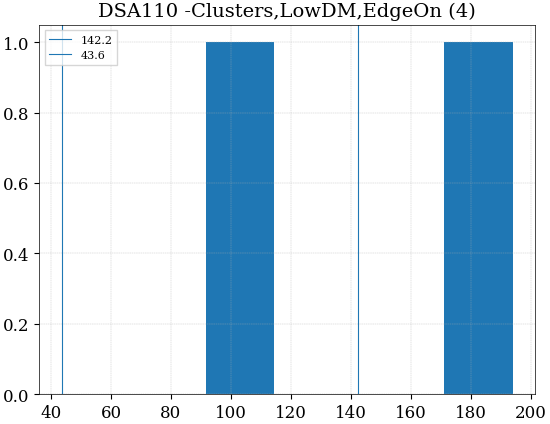

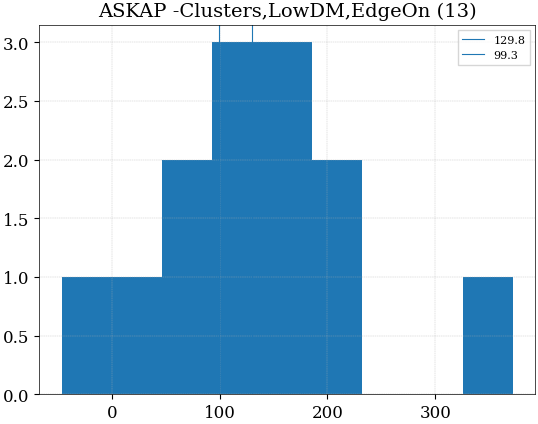

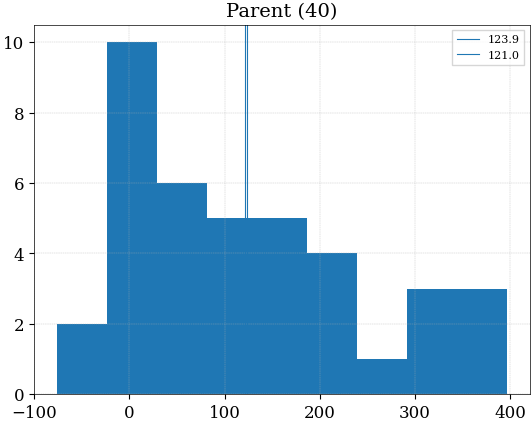

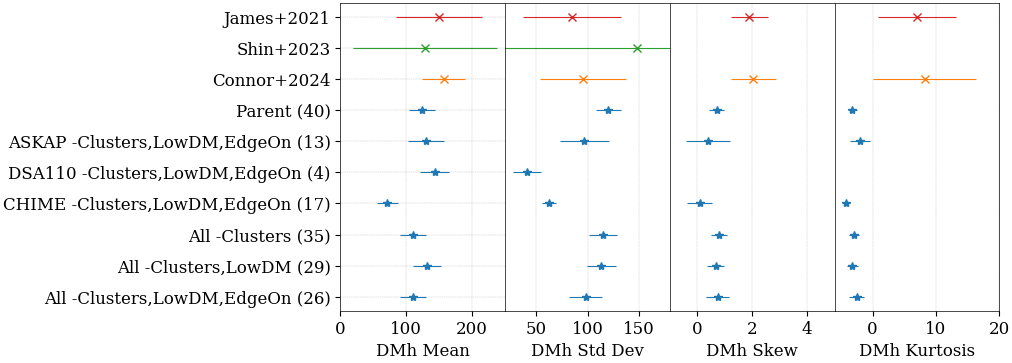

In [956]:
ds_compilation = []
ds_compilation.append(analyze_sample(remove_clusters_lowdm_edgeon,diagnostic = True,
               label = 'All -Clusters,LowDM,EdgeOn',sigma_igm='none'))
ds_compilation.append(analyze_sample(remove_clusters_lowdm,diagnostic = True,
               label = 'All -Clusters,LowDM',sigma_igm='none'))
ds_compilation.append(analyze_sample(remove_clusters,diagnostic = True,
               label = 'All -Clusters',sigma_igm='none'))
ds_compilation.append(analyze_sample(all_chime,diagnostic = True,
               label = 'CHIME -Clusters,LowDM,EdgeOn',sigma_igm='none'))
ds_compilation.append(analyze_sample(all_dsa,diagnostic = True,
               label = 'DSA110 -Clusters,LowDM,EdgeOn',sigma_igm='none'))
ds_compilation.append(analyze_sample(all_askap,diagnostic = True,
               label = 'ASKAP -Clusters,LowDM,EdgeOn',sigma_igm='none'))
ds_compilation.append(analyze_sample(parent,diagnostic = True,
               label = 'Parent',sigma_igm='none'))
f,axs = plt.subplots(ncols = 4, nrows = 1,figsize = (8.5,4))
f.subplots_adjust(wspace=0)

for ii in [0,1,2,3]: # get each moment
    axs[ii].errorbar(x =[d[0][ii][0] for d in ds_compilation], 
                 xerr = [d[0][ii][1] for d in ds_compilation],
                    y = [d[1] for d in ds_compilation],linestyle = 'none',marker = '*')

    axs[ii].errorbar(x = [connor_vsk[ii][0]],
                 xerr = [connor_vsk[ii][1]],
                     y = ['Connor+2024'],marker = 'x')
    if ii < 2:
        axs[ii].errorbar(x = [shin_vsk[ii][0]],
                     xerr = [shin_vsk[ii][1]],
                         y = ['Shin+2023'],marker = 'x')
    else:
        axs[ii].errorbar(x = [-999],xerr = [1],y = ['Shin+2023'],marker = 'x') # hide Kaitlyn measurements
    axs[ii].errorbar(x = [james_vsk[ii][0]],
                 xerr = [james_vsk[ii][1]],
                     y = ['James+2021'],marker = 'x')

    
axs[1].get_yaxis().set_visible(False)
axs[2].get_yaxis().set_visible(False)
axs[3].get_yaxis().set_visible(False)

axs[0].set_xlabel('DMh Mean')
axs[1].set_xlabel('DMh Std Dev') 
axs[2].set_xlabel('DMh Skew') 
axs[3].set_xlabel('DMh Kurtosis') 

axs[0].set_xlim(0,250)
axs[1].set_xlim(20,180)
axs[2].set_xlim(-1,5)
axs[3].set_xlim(-6,20)
plt.savefig('mvsk.pdf',dpi = 110)

# Order the waterfalls

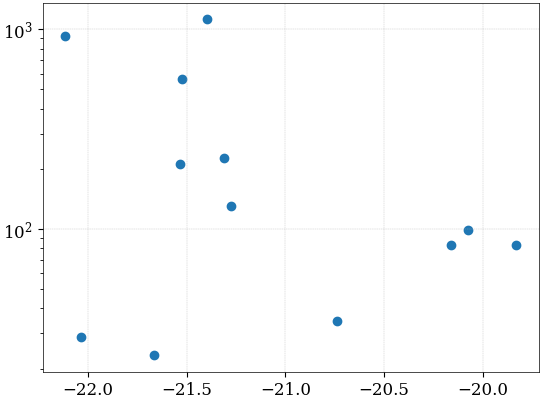

In [929]:
plt.figure()
plt.scatter(final_zspec['M_r'][leung_keep],
            final_zspec['fluence'][leung_keep] * 4 * np.pi* Planck18.luminosity_distance(final_zspec['primary_z_spec'][leung_keep])**2 / 1e6)
plt.yscale('log')

In [930]:
plt.figure()
plt.scatter(final['primary_z_spec'],final['primary_mag'] - final['extinction_mags'] - dist_mod)
for x,y,s in zip(final['primary_z_spec'],final['primary_mag'] - final['extinction_mags'] - dist_mod,final.index):
    if (y > -16 or y < -23) and x > 0:
        print(s)
        plt.text(x,y,s=s)
plt.xscale('log')

NameError: name 'dist_mod' is not defined

<Figure size 640x480 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
# Fiducial measurement: PATH P(O|x) > 0.9; m_r < 19.5; Use z_spec
fiducial = (final['primary_P_Ox'] > 0.9) * (final['primary_mag'] < 19.5) * (final['primary_z_spec'] > 0)
# Impact of relaxing PATH:
fiducial_lower_pox = (final['primary_P_Ox'] > 0.5) * (final['primary_mag'] < 19.5) * (final['primary_z_spec'] > 0)

fiducial_fainter_mag=(final['primary_P_Ox'] > 0.9) * (final['primary_mag'] < 22) * (final['primary_z_spec'] > 0)

plt.style.use('/arc/home/calvin/kko_host_paper/plot_scripts/paper_sty.mplstyle')
bins = np.linspace(0,400,num = 10)
dm_host = (final['DM'] - final['dm_igm'] - final['DM_NE2001'] - final['DM_YT20']) / (1 + final['primary_z_spec'])
plt.figure()
plt.hist(dm_host[fiducial_lower_pox],label = 'Lower P(O|x)',bins = bins,alpha = 0.3)
plt.figure()
plt.hist(dm_host[fiducial_fainter_mag],label = 'Fiducial',bins = bins,alpha = 0.3)
plt.figure()
plt.hist(dm_host[fiducial],label = '$m_r$ < 22',bins = bins,alpha = 0.3)
rest_frame_merger_dm = dm_host[final.index == 342256558].values / (1 + final['primary_z_spec'][final.index == 342256558].values)
plt.axvline(rest_frame_merger_dm,color = 'black',linestyle = '--')
plt.text(x = rest_frame_merger_dm + 10,y = 2.1,s = 'Galaxy Merger Host\n (FRB20231204A)',rotation = 90)
plt.legend()
plt.xlabel('Host Galaxy DM')
plt.ylabel('Number')
[mu,sig],[mu_err,sig_err] = fit_mu_sigma(np.log10(dm_host[fiducial]))
print(f"$\mu = {mu:.2f} \pm {mu_err:.2f}$, $\sigma={sig:.2f} \pm {sig_err:.2f}$")
[mu,sig],[mu_err,sig_err] = fit_mu_sigma(np.log10(dm_host[fiducial_lower_pox]))
print(f"$\mu = {mu:.2f} \pm {mu_err:.2f}$, $\sigma={sig:.2f} \pm {sig_err:.2f}$")
[mu,sig],[mu_err,sig_err] = fit_mu_sigma(np.log10(dm_host[fiducial_fainter_mag]))
print(f"$\mu = {mu:.2f} \pm {mu_err:.2f}$, $\sigma={sig:.2f} \pm {sig_err:.2f}$")
plt.savefig('/arc/home/calvin/kko_host_paper/figures/dm_host.pdf',dpi=100)

In [349]:
final[(final['primary_P_Ox'] > 0.9) * (final['primary_z_spec'] > 0)][['name','primary_z_spec']]

,name,primary_z_spec
chime_event_id,,
325140573,FRB20231005A,0.0713
342256558,FRB20231204A,0.0644
339589360,FRB20231128A,0.1079
347082860,FRB20231223C,0.1059
330976597,FRB20231025B,0.3238
328261629,FRB20231017A,0.2450
321977347,FRB20230926A,0.0553
338403209,FRB20231123A,0.0729
326456063,FRB20231011A,0.0783


# Inclination measurements

In [ ]:
chime_id  TNS name     ra        dec       - inclinet using SDSS image - inclinet using deeper Pan-STARRS image
325140573 FRB20231005A 246.027572 35.446989 - 82,1          - 82, 0
342256558 FRB20231204A 207.999403 48.120566 - double galaxy - omit, double galaxy
339589360 FRB20231128A 199.580129 42.999713 - too faint     - 56, 3
347082860 FRB20231223C 259.544432 29.495848 - 49, 1         - 53,55; spiral structure visble so i think inclinet is wrong
330976597 FRB20231025B 270.786050 63.985568 - unresolved    - rejected 95%
330838705 FRB20231025C 71.974285 33.237527 - outside SDSS  - rejected 98%
328261629 FRB20231017A 346.753314 36.648447 - outside SDSS  - 69, 4 rejected 98%
321977347 FRB20230926A 269.124186 41.809999 - 73, 1         - 76, 1
338403209 FRB20231123A 82.622632 4.474384  - outside       - reject 99
341758878 FRB20231202A 65.030607 38.632866 - outside       - too faint
341477821 FRB20231201A 54.587601 26.812848 - outside       - 64, 4, reject 89%
326456063 FRB20231011A 18.241706 41.748995 - outside       - 
300938875 FRB20230703A 184.622792 48.725034 - irregular     - reject 100%
306528286 FRB20230730A 54.664905 33.160664 - outside       - faint
268786306 FRB20230203A 151.663820 35.697150 - 77, 1         - 81, 2
272350056 FRB20230222A 106.960492 11.222877 - outside       - no image?
272367619 FRB20230222B 238.737954 30.899874 - 48, 0 - 50, 5, 83% reject
342760050 FRB20231206A 112.443123 56.253245 - outside - 76, 1
325442526 FRB20231007B 307.529411 72.887196 - outside - 63, 6, 93% reject